### Install Packages and Import Dataset

In this notebook, we’ll be working with the **Wisconsin Diagnostic Breast Cancer (WDBC)** dataset. This dataset is commonly used in machine learning tasks related to classification, and it contains several features derived from digitized images of breast tumor cells obtained via fine needle aspirates (FNAs).

Each row in the dataset represents one tumor, with a set of measurements calculated from the cell nuclei present in the image. The dataset has the following columns:
- **ID**: Unique identifier for each tumor sample.
- **Diagnosis**: The classification label for the tumor (Malignant or Benign).
- **Radius Mean, Texture Mean, Perimeter Mean, Area Mean**: Various statistical properties of the tumor.
- **Compactness, Concavity, Symmetry**: Other characteristics calculated from the shape and structure of the tumor cells.

The target column is **Diagnosis**, which we will try to predict based on the other features in the dataset.

This dataset was obtained from the UCI Machine Learning Repository, a well-known resource for datasets in the machine learning community.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits import mplot3d

In [3]:
cancer = pd.read_csv('dataset/wdbc.csv')
cancer

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


### What is Pandas?

"But wait, what is that `pd.read_csv()` thing?" Well, it comes from **pandas**, a powerful Python library designed for data manipulation and analysis. 

Pandas allows us to efficiently handle datasets, similar to how you would in Excel, but with far more capabilities. It can handle large datasets and perform complex transformations with just a few lines of code.

The `pd.read_csv()` function is used to load data from a CSV file into a **DataFrame**, which is like a table of data with rows and columns. Each column can hold different types of data (e.g., numbers, text), making it a versatile structure for analysis.

By using pandas in this notebook, we can:
- Load and explore the dataset easily.
- Identify missing or problematic data.
- Group, sort, and manipulate data efficiently.
- Prepare the data for machine learning or statistical analysis.

As we move forward on our journey, you'll see how pandas simplifies a lot of the heavy lifting in data science!

### Inspect the data

The `.info()` method in pandas provides a concise summary of a DataFrame, including the dtype, column names, and non-null values. It’s particularly useful for getting an overview of the dataset's structure and identifying any missing data.

In [5]:
cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [7]:
cancer.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



The `.unique()` method in pandas returns the unique values in a column. This method is useful for identifying all distinct values within a dataset, especially when you want to see the different categories or groups present in a column.

In [9]:
cancer["diagnosis"].unique()

array(['M', 'B'], dtype=object)

Clean data by renaming "M" to "Malignant" and "B" to "Benign" using the `.replace` method. The `.replace` method takes one argument: a dictionary that maps previous values to desired new values.

In [11]:
cancer["diagnosis"] = cancer["diagnosis"].replace({
    "M" : "Malignant",
    "B" : "Benign"
})

cancer["diagnosis"].unique()

array(['Malignant', 'Benign'], dtype=object)


To analyze the distribution of benign and malignant tumor observations in the dataset, we can use the `.groupby` and `.size` methods with pandas.

Group the Data by the Class Variable:

1. Use `.groupby` on the Class column to group the data by benign and malignant tumor observations.
Count the Observations:

2. Apply the `.size` method to count the number of observations in each group.

Calculate Percentages:

3. Divide the counts by **the total number of observations** (found using `df.shape`[0]) and multiply by 100 to get the percentage.

In [13]:
100 * cancer.groupby("diagnosis").size() / cancer.shape[0]

diagnosis
Benign       62.741652
Malignant    37.258348
dtype: float64

The `.value_counts` method in pandas efficiently counts the occurrences of each unique value in a column.

In [15]:
cancer["diagnosis"].value_counts()

diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

 By using the `normalize=True` argument, it can also return the fraction (or percentage) of each value, providing a quick and convenient way to analyze the distribution of data.

In [17]:
cancer["diagnosis"].value_counts(normalize=True)

diagnosis
Benign       0.627417
Malignant    0.372583
Name: proportion, dtype: float64

### Visualizing the Data

Now, let’s create a scatter plot to visualize the relationship between **perimeter mean** and **concavity mean**. This will help us see how these features relate to whether a tumor is benign or malignant.

_The code below may look a bit intimidating, but don’t worry! You don’t need to understand every line right now. It uses matplotlib to create the plot and map different colors to the benign and malignant tumor groups._

_Even if this feels complex, the key takeaway is seeing how we can visualize patterns in the data. Later, as you get more familiar with plotting, you can revisit this code to dissect it further._

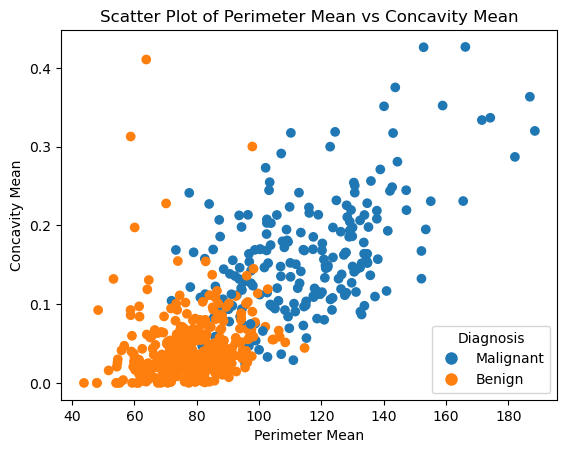

In [19]:
# Create mapping between values and colors
labels = cancer["diagnosis"].unique().tolist()
colors = list(mcolors.TABLEAU_COLORS.keys())
color_map = {l: colors[i % len(colors)] for i, l in enumerate(labels)}

# Plot
plt.scatter(cancer["perimeter_mean"], cancer['concavity_mean'], 
            color=cancer["diagnosis"].map(color_map))

# Create custom legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markersize=10, markerfacecolor=color_map[label])
           for label in labels]

# Add labels and legend
plt.xlabel('Perimeter Mean')
plt.ylabel('Concavity Mean')
plt.title('Scatter Plot of Perimeter Mean vs Concavity Mean')
plt.legend(handles=handles, title='Diagnosis')
plt.show()


_It’s okay if you don’t grasp everything right away—focus on understanding the output and come back to the code when you’re ready!_

- **Malignant Observations**: These tend to be located in the upper right-hand corner of the plot (blue), indicating higher values for both concavity and perimeter.
- **Benign Observations**: These are generally found in the lower left-hand corner (orange), suggesting lower values for concavity and perimeter.

This visual pattern suggests that it may be possible to predict the diagnosis of new tumor images by using their concavity and perimeter mean values.

### K-Nearest Neighbors Manually

In this section, we’ll manually implement the K-nearest neighbors (KNN) algorithm to classify a new data point. The idea behind KNN is simple: given a new observation, the algorithm looks at the "K" closest points in the dataset and assigns the class (benign or malignant) based on the majority class of its neighbors.

We’ll plot the existing data and add a new observation to the plot, then calculate the distances between the new point and the other points in the dataset to find its nearest neighbors.

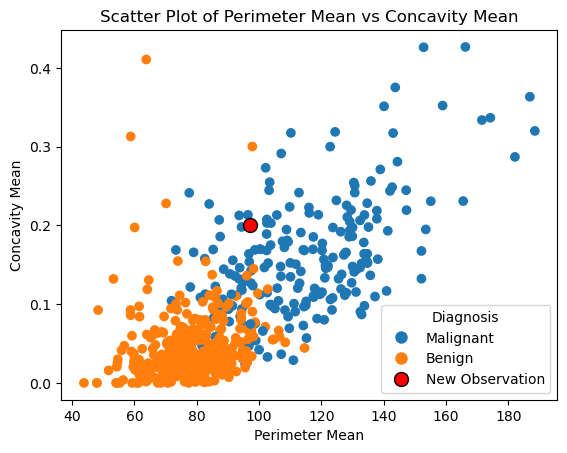

In [21]:
# Plot existing data
plt.scatter(cancer["perimeter_mean"], cancer['concavity_mean'], 
            color=cancer["diagnosis"].map(color_map))

# Create custom legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markersize=10, markerfacecolor=color_map[label])
           for label in labels]

# Add new observation
new_observation = {'perimeter_mean': 97, 'concavity_mean': 0.20}
plt.scatter(new_observation['perimeter_mean'], new_observation['concavity_mean'],
            color='red', edgecolor='black', s=100, label='New Observation')

# Add labels and legend
plt.xlabel('Perimeter Mean')
plt.ylabel('Concavity Mean')
plt.title('Scatter Plot of Perimeter Mean vs Concavity Mean')
plt.legend(handles=handles + [plt.Line2D([0], [0], marker='o', color='w', 
                                          markerfacecolor='red', markeredgecolor='black', 
                                          markersize=10, label='New Observation')], 
           title='Diagnosis')
plt.show()

To find the $K$ nearest neighbors to our new observation, we compute the distance from that new observation to each observation in our training data, and select the $K$ observations corresponding to the smallest distance values. For example, suppose we want to use $K= 5$ neighbors to classify a new observation with mean perimeter 97 and concavity 0.20. We can calculate the distances between our new point and each of the observations in the training set to find the $5$ neighbors that are nearest to our new point. 

$$
Distance = \sqrt{(x_B - x_A)^2 + (y_B - y_A)^2}
$$


 In order to find the $K = 5$ nearest neighbors, we will use the `nsmallest` function from pandas.

In [10]:
new_obs_Perimeter = 97
new_obs_Concavity = 0.20
cancer["dist_from_new"] = (
       (cancer["perimeter_mean"] - new_obs_Perimeter) ** 2
     + (cancer["concavity_mean"] - new_obs_Concavity) ** 2
)**(1/2)

nearest_5 = cancer.nsmallest(5, "dist_from_new")[[
    "perimeter_mean",
    "concavity_mean",
    "diagnosis",
    "dist_from_new"
]]

nearest_5

,perimeter_mean,concavity_mean,diagnosis,dist_from_new
291,97.03,0.05940,Benign,0.143765
138,96.85,0.15390,Malignant,0.156924
15,96.73,0.16390,Malignant,0.272403
514,97.26,0.07486,Malignant,0.288548
54,97.26,0.05253,Malignant,0.298910


 Tumor Data with Distance Calculations

| Perimeter Mean | Concavity Mean | Distance                                      | Diagnosis     |
|----------------|----------------|-----------------------------------------------|---------------|
| 97.03          | 0.05940        | $\sqrt{(97.03 - 97)^2 + (0.05940 - 0.20)^2}$ | Benign        |
| 96.85          | 0.15390        | $\sqrt{(96.85 - 97)^2 + (0.15390 - 0.20)^2}$ | Malignant     |
| 96.73          | 0.16390        | $\sqrt{(96.73 - 97)^2 + (0.16390 - 0.20)^2}$ | Malignant     |
| 97.26          | 0.07486        | $\sqrt{(97.26 - 97)^2 + (0.07486 - 0.20)^2}$ | Malignant     |
| 97.26          | 0.05253        | $\sqrt{(97.26 - 97)^2 + (0.05253 - 0.20)^2}$ | Malignant        |



The result of this computation shows that 4 of the 5 nearest neighbors to our new observation are malignant

### What if we have more than 2 variables?

So far, we’ve only looked at the relationship between two features: **perimeter mean** and **concavity mean**. But what if we want to include more features in our analysis? In that case, we can extend our scatter plot into three dimensions to visualize how a third feature (in this case, **symmetry mean**) interacts with the others.

This 3D scatter plot will help us see if adding another feature might give us more insight into classifying the data. By visualizing multiple features at once, we can start to understand how they work together to differentiate benign from malignant tumors.

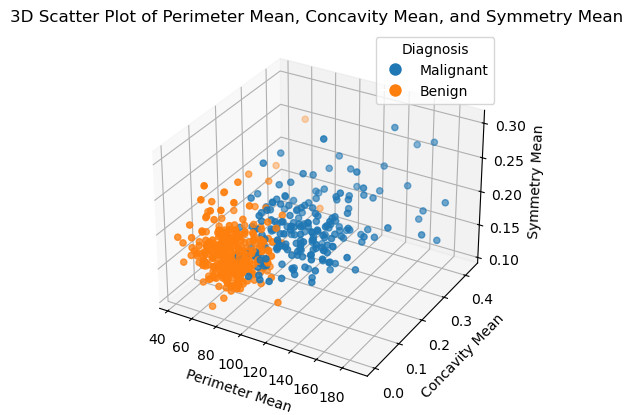

In [23]:
# Create mapping between values and colors
labels = cancer["diagnosis"].unique().tolist()
colors = list(mcolors.TABLEAU_COLORS.keys())
color_map = {l: colors[i % len(colors)] for i, l in enumerate(labels)}

# Create a 3D plot
ax = plt.axes(projection="3d")

# Plot data points with color corresponding to diagnosis
sc = ax.scatter3D(cancer['perimeter_mean'], cancer['concavity_mean'], cancer['symmetry_mean'], 
                  c=cancer['diagnosis'].map(color_map), marker='o')

# Add axis labels
ax.set_xlabel('Perimeter Mean')
ax.set_ylabel('Concavity Mean')
ax.set_zlabel('Symmetry Mean')
ax.set_title('3D Scatter Plot of Perimeter Mean, Concavity Mean, and Symmetry Mean')

# Create custom legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markersize=10, markerfacecolor=color_map[label])
           for label in labels]

# Add legend
plt.legend(handles=handles, title='Diagnosis')

# Show plot
plt.show()


Suppose we want to use $K= 5$ neighbors to classify a new observation with a perimeter of 97, concavity of 0.20, and symmetry of 0.22. 

$$
Distance = \sqrt{(x_B - x_A)^2 + (y_B - y_A)^2 + (z_B - z_A)^2}
$$

<module 'matplotlib.pyplot' from 'C:\\Users\\eluba\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

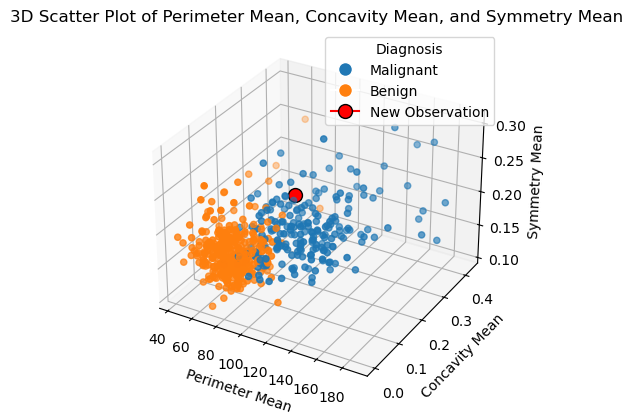

In [26]:
# Create mapping between values and colors
labels = cancer["diagnosis"].unique().tolist()
colors = list(mcolors.TABLEAU_COLORS.keys())
color_map = {l: colors[i % len(colors)] for i, l in enumerate(labels)}

# Create a 3D plot
ax = plt.axes(projection="3d")

# Plot data points with color corresponding to diagnosis
sc = ax.scatter3D(cancer['perimeter_mean'], cancer['concavity_mean'], cancer['symmetry_mean'], 
                  c=cancer['diagnosis'].map(color_map), marker='o')

# Define the new observation
new_observation = {'perimeter_mean': 97, 'concavity_mean': 0.20, 'symmetry_mean': 0.22}

# Plot the new observation
ax.scatter3D(new_observation['perimeter_mean'], new_observation['concavity_mean'], 
             new_observation['symmetry_mean'], color='red', edgecolor='black', 
             s=100, marker='o', label='New Observation')

# Add axis labels
ax.set_xlabel('Perimeter Mean')
ax.set_ylabel('Concavity Mean')
ax.set_zlabel('Symmetry Mean')
ax.set_title('3D Scatter Plot of Perimeter Mean, Concavity Mean, and Symmetry Mean')

# Create custom legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markersize=10, markerfacecolor=color_map[label])
           for label in labels]

# Add custom legend for new observation
handles.append(plt.Line2D([0], [0], marker='o', color='red', label='New Observation', 
                          markersize=10, markeredgecolor='black'))

# Add legend
plt.legend(handles=handles, title='Diagnosis')

# Show plot
plt


In [28]:
new_obs_Perimeter = 97
new_obs_Concavity = 0.20
new_obs_Symmetry = 0.22
cancer["dist_from_new"] = (
      (cancer["perimeter_mean"] - new_obs_Perimeter) ** 2
    + (cancer["concavity_mean"] - new_obs_Concavity) ** 2
    + (cancer["symmetry_mean"] - new_obs_Symmetry) ** 2
)**(1/2)
cancer.nsmallest(5, "dist_from_new")[[
    "perimeter_mean",
    "concavity_mean",
    "symmetry_mean",
    "diagnosis",
    "dist_from_new"
]]

,perimeter_mean,concavity_mean,symmetry_mean,diagnosis,dist_from_new
291,97.03,0.05940,0.1879,Benign,0.147305
138,96.85,0.15390,0.1957,Malignant,0.158795
15,96.73,0.16390,0.2303,Malignant,0.272597
514,97.26,0.07486,0.1561,Malignant,0.295539
54,97.26,0.05253,0.1616,Malignant,0.304562


Based on $K = 5$ nearest neighbors with these three predictors we would classify the new observation as malignant since 4 out of 5 of the nearest neighbors are malignant class. 

#### K-Nearest Neighbours using `scikit-learn`

Coding the K-nearest neighbors algorithm from scratch in Python can become complex, particularly when dealing with multiple classes, more than two variables, or predicting the class for several new observations.

 Fortunately, Python's `scikit-learn` package offers a built-in implementation of the KNN algorithm. This implementation simplifies the process, making our code more readable, accurate, and less prone to errors. 


 To ensure compatibility with pandas DataFrames when using scikit-learn, it's important to configure the package appropriately using the `set_config` function before starting with KNN.

In [32]:
from sklearn import set_config

# Output dataframes instead of arrays
set_config(transform_output="pandas")

Step 1. import the `KNeighborsClassifier` from the `sklearn.neighbors` module.

In [34]:
from sklearn.neighbors import KNeighborsClassifier

Similar to above, we will use perimeter mean and concavity mean as predictors and 
$K = 5$ neighbors to build our classifier.

In [36]:
cancer_train = cancer[["diagnosis", "perimeter_mean", "concavity_mean"]]
cancer_train

,diagnosis,perimeter_mean,concavity_mean
0,Malignant,122.80,0.30010
1,Malignant,132.90,0.08690
2,Malignant,130.00,0.19740
3,Malignant,77.58,0.24140
4,Malignant,135.10,0.19800
...,...,...,...
564,Malignant,142.00,0.24390
565,Malignant,131.20,0.14400
566,Malignant,108.30,0.09251
567,Malignant,140.10,0.35140


Step 2. Create a model object for K-nearest neighbors classification by creating a `KNeighborsClassifier` instance, specifying that we want to use $K = 5$ neighbors

In [38]:
knn = KNeighborsClassifier(n_neighbors=5)
knn

KNeighborsClassifier()

Step 3. Fit the model on the breast cancer data. 
The `X` argument is used to specify the data for the predictor variables, while the `y` argument is used to specify the data for the response variable. 

Here, 
- `X=cancer_train[["perimeter_mean", "concavity_mean"]]` *to specify both Perimeter and Concavity means are to be used as the predictors.* 
- `y=cancer_train["diagnosis"]` *to specify that diagnosis is the response variable (the one we want to predict)* 

In [40]:
knn.fit(X=cancer_train[["perimeter_mean", "concavity_mean"]], y=cancer_train["diagnosis"])

KNeighborsClassifier()

Step 4. Make a prediction on a new observation by calling `.predict` on the classifier object, passing the new observation itself.

In [42]:
new_obs = pd.DataFrame({"perimeter_mean": [97], "concavity_mean": [0.20]})
knn.predict(new_obs)

array(['Malignant'], dtype=object)

Prediction is the same as what we manually computed above!

### Conclusion

In this notebook, we worked through several steps to classify tumors as either benign or malignant using the Wisconsin Diagnostic Breast Cancer dataset. Here's a summary of what we covered:
  
1. **Data Loading and Exploration**: We used pandas to load and inspect the dataset, identifying key features and understanding the structure of the data.
2. **Data Visualization**: We created scatter plots to visualize the relationships between important features such as **perimeter mean** and **concavity mean**. These visualizations helped us see the separation between benign and malignant tumors.
3. **K-Nearest Neighbors Algorithm (KNN)**: We manually implemented the KNN algorithm, calculating distances to classify a new observation. This showed how KNN works by finding the closest neighbors to predict a class.
4. **Extending to More Variables**: We extended our analysis to three variables using a 3D scatter plot, demonstrating that more features can provide additional insights for classification tasks.
  
By the end, we also used the `scikit-learn` library to automate the KNN process, making the classification task simpler and more efficient. We hope this notebook has given you a hands-on understanding of data visualization, classification, and the practical use of machine learning algorithms like KNN. Don’t hesitate to experiment more with the dataset or the code to deepen your learning!


### Install Packages and Import Dataset

In this notebook, we’ll be working with the **Wisconsin Diagnostic Breast Cancer (WDBC)** dataset again. As a reminder, this dataset contains several features derived from digitized images of breast tumor cells obtained via fine needle aspirates (FNAs).

Each row in the dataset represents one tumor, with a set of measurements calculated from the cell nuclei present in the image. The dataset has the following columns:
- **ID**: Unique identifier for each tumor sample.
- **Diagnosis**: The classification label for the tumor (Malignant or Benign).
- **Radius Mean, Texture Mean, Perimeter Mean, Area Mean**: Various statistical properties of the tumor.
- **Compactness, Concavity, Symmetry**: Other characteristics calculated from the shape and structure of the tumor cells.

The target column is **Diagnosis**, which we will try to predict based on the other features in the dataset.

This dataset was obtained from the UCI Machine Learning Repository, a well-known resource for datasets in the machine learning community.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score, precision_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

In [3]:
cancer = pd.read_csv('dataset/wdbc.csv')
cancer

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


#### Clean data 
by renaming "M" to "Malignant" and "B" to "Benign" using the `.replace` method. The `.replace` method takes one argument: a dictionary that maps previous values to desired new values.

In [5]:
cancer["diagnosis"] = cancer["diagnosis"].replace({
    "M" : "Malignant",
    "B" : "Benign"
})

cancer["diagnosis"].unique()

array(['Malignant', 'Benign'], dtype=object)

#### Scale data 
by standardizing our features in the dataset, to make sure theyre on the same scale. As we've seen, differences in scale can disproportionately affect machine learning models that rely on distance metrics (e.g., K-Nearest Neighbors). 
The `StandardScaler()` function in the sklearn.preprocessing module is a widely used tool for this purpose.

In [11]:
# Create a copy of the original 'cancer' dataframe to ensure we're not modifying the original data
standardized_cancer = cancer.copy()

# Specify the columns that we do NOT want to scale (ID and diagnosis columns)
columns_to_exclude = ['id', 'diagnosis']

# Select the columns that we want to scale by excluding the 'id' and 'diagnosis' columns
# This will return a list of the numeric columns we need to scale
columns_to_scale = standardized_cancer.columns.difference(columns_to_exclude)

# Initialize the StandardScaler to standardize the selected numeric columns
scaler = StandardScaler()

# Apply the scaler to the selected columns. This transforms the data so that each feature
# has a mean of 0 and a standard deviation of 1, which is essential to prevent larger
# scale features from dominating the analysis, especially for distance-based algorithms like KNN.
standardized_cancer[columns_to_scale] = scaler.fit_transform(cancer[columns_to_scale])

# Output the standardized dataframe with the scaled numeric columns
standardized_cancer


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,Malignant,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,842517,Malignant,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,84300903,Malignant,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,84348301,Malignant,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,84358402,Malignant,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,Malignant,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,...,1.901185,0.117700,1.752563,2.015301,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091
565,926682,Malignant,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,...,1.536720,2.047399,1.421940,1.494959,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978
566,926954,Malignant,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,...,0.561361,1.374854,0.579001,0.427906,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409
567,927241,Malignant,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,...,1.961239,2.237926,2.303601,1.653171,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635


### Evaluating Performance

In Python, the `scikit-learn package` helps both with building a classifier as well as evaluating its performance.

**Golden rule of machine learning**: you cannot use the test data to build the model! If you do, the model gets to “see” the test data in advance, making it look more accurate than it really is. 

How about simplifying it like this:

*Imagine how dangerous it could be if your model incorrectly predicts a patient’s tumor is benign when it’s actually malignant. Overestimating the accuracy of your model could lead to serious mistakes like that.*

Typically, when splitting data for classification tasks, we divide it into a training set and a test set to evaluate the model's performance. The training set, which usually makes up 50% to 95% of the total data, is used to help the model learn patterns and relationships. The remaining 5% to 50% is set aside as the test set, which is used to assess how well the model can handle new, unseen data.

Think of it like preparing a doctor for an exam where they need to decide whether a tumor is cancerous or not. The training set is like the doctor’s study material—cases they practice with to get familiar with the symptoms and patterns of cancerous tumors. But you wouldn’t want to give them all the cases upfront. You need to reserve some unseen cases for the real test, which is where the test set comes in. These are the new cases the doctor faces during the exam, and the goal is to see how well they can apply their learning to fresh examples. If they perform well on the test cases, it shows that they’ve truly understood the task and aren’t just memorizing the practice cases.

In practice, a 75/25 or 80/20 split is common for classification tasks, meaning 75% of the data is used for training and 25% for testing. This balance ensures the model has enough data to learn effectively, while still reserving a significant portion to evaluate how well it performs on new, unseen data. This approach helps prevent overfitting, where the model performs well on the training data but struggles with real-world examples.

For this example, we’ll use 75% of the data for training—so the model has enough information to learn patterns—and 25% for testing, to ensure we have a reliable measure of its performance on unseen cases."

The `train_test_split` function from scikit-learn simplifies data splitting. Key parameters to consider are:

- **`shuffle=True`** (default): Shuffles the data before splitting to avoid any ordering effects.
- **`stratify`**: Ensures the training and testing sets maintain the same class distribution as the original data. For example, if 63% of your data is benign and 37% malignant, using `stratify` ensures these proportions are preserved in both sets.

For reproducibility, we will set a random seed using numpy's `random.seed` function

#### What is NumPy?

"But wait, what is that `np.random.seed()` thing?". It comes from **NumPy**, a popular Python library that helps us work with numbers and do math really fast, especially when dealing with large amounts of data. It's great for things like handling lists of numbers, performing calculations, and generating random numbers.

The `np.random.seed()` function is used to control the randomness in your code. Normally, when we generate random numbers, they change every time we run the code. By setting a "seed" with `np.random.seed()`, we make sure the random numbers stay the same each time we run it. This is useful when we want consistent results for testing or comparisons.
NumPy arrays are fast and powerful, allowing us to do all sorts of math and number operations easily!

In [13]:
# set the seed
np.random.seed(1)

#split the data
cancer_train, cancer_test = train_test_split(
    standardized_cancer, train_size=0.75, stratify=standardized_cancer["diagnosis"]
)

The `info` method shows that the training set has 426 observations and the test set has 143, reflecting a 75%/25% split. To check diagnosis distribution, use `value_counts(normalize=True)` on `cancer_train`. This reveals about 63% benign and 37% malignant cases, confirming that the class proportions were maintained in the split.

In [15]:
cancer_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 426 entries, 164 to 284
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       426 non-null    int64  
 1   diagnosis                426 non-null    object 
 2   radius_mean              426 non-null    float64
 3   texture_mean             426 non-null    float64
 4   perimeter_mean           426 non-null    float64
 5   area_mean                426 non-null    float64
 6   smoothness_mean          426 non-null    float64
 7   compactness_mean         426 non-null    float64
 8   concavity_mean           426 non-null    float64
 9   concave points_mean      426 non-null    float64
 10  symmetry_mean            426 non-null    float64
 11  fractal_dimension_mean   426 non-null    float64
 12  radius_se                426 non-null    float64
 13  texture_se               426 non-null    float64
 14  perimeter_se             426 

In [17]:
cancer_train["diagnosis"].value_counts(normalize=True)

diagnosis
Benign       0.626761
Malignant    0.373239
Name: proportion, dtype: float64

Recall Notebook 1 (Classification 1):

Fit the model on the breast cancer data. 

The `X` argument specifies the predictor variables (independent variables), while the `y` argument specifies the response variable (dependent variable).

Here, 
- `X=cancer_train[["perimeter_mean", "concavity_mean"]]` *to specify both Perimeter and Concavity means are to be used as the predictors.* 
- `y=cancer_train["diagnosis"]` *to specify that diagnosis is the response variable (the one we want to predict)* 

In [19]:
knn = KNeighborsClassifier(n_neighbors=5)
knn

KNeighborsClassifier()

In [21]:
knn.fit(X=cancer_train[["perimeter_mean", "concavity_mean"]], y=cancer_train["diagnosis"])

KNeighborsClassifier()

Using the K-nearest neighbors classifier, we can predict whether each case in the test set is cancerous or not. We then compare these predictions with the actual diagnoses. The `diagnosis` column shows the actual results, and the `predicted` column shows what our classifier predicted. We'll display only the `ID`, `diagnosis`, and `predicted` columns from the test set to assess the classifier's performance.

In [23]:
cancer_test["predicted"] = knn.predict(cancer_test[["perimeter_mean", "concavity_mean"]])
cancer_test[["id", "diagnosis", "predicted"]]

,id,diagnosis,predicted
357,901028,Benign,Benign
361,901041,Benign,Benign
212,8810703,Malignant,Malignant
527,91813702,Benign,Benign
21,8510824,Benign,Benign
...,...,...,...
364,9010877,Benign,Benign
434,908469,Benign,Benign
299,892399,Benign,Benign
488,913512,Benign,Benign


Since we don't know how good our predictions are, we need to measure their accuracy. One way to assess how well our predictions match the actual labels in the test set is by calculating the **prediction accuracy**.

$
\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}
$

We can examine accuracy using the `score` method. Here, we pass the test data (predictors) and the actual labels (`cancer_test["diagnosis"]`) to the method. This will evaluate how well the classifier's predictions match the true labels.

In [27]:
knn.score(
    cancer_test[["perimeter_mean", "concavity_mean"]],
    cancer_test["diagnosis"]
)

0.9230769230769231

The output shows that the estimated accuracy of the classifier on the test data was 88%!

Accuracy is a simple and widely used measure to summarize a classifier's performance. However, it only shows how often the model is correct overall and doesn't provide insight into the types of errors it makes. To get a clearer picture, you can use a **confusion matrix**.

### What is a Confusion Matrix?

A confusion matrix breaks down the number of correct and incorrect predictions for each class, revealing the specific kinds of mistakes the classifier tends to make.

**True Positive:** A malignant observation that was classified as malignant (top left).

**False Positive:** A benign observation that was classified as malignant (bottom left).

**True Negative:** A benign observation that was classified as benign (bottom right).

**False Negative:** A malignant observation that was classified as benign (top right).

<table>
  <tr>
    <th></th>
    <th>Predicted Malignant</th>
    <th>Predicted Benign</th>
  </tr>
  <tr>
    <th>Actually Malignant</th>
    <td>True Positive</td>
    <td>False Negative</td>
  </tr>
  <tr>
    <th>Actually Benign</th>
    <td>False Positive</td>
    <td>True Negative</td>
  </tr>
</table>

To view the confusion matrix, we can use the `crosstab` function from pandas. Here, we provide the actual labels as the first argument and the predicted labels as the second argument. 

*Note* that crosstab orders columns alphabetically, so the positive label (Malignant) might not appear in the top left corner but will still be correctly labeled.

In [29]:
pd.crosstab(
    cancer_test["diagnosis"],
    cancer_test["predicted"]
)

predicted,Benign,Malignant
diagnosis,,
Benign,88,2
Malignant,9,44


The confusion matrix reveals the following:

- 44 observations were correctly predicted as malignant.
- 88 observations were correctly predicted as benign.
- 9 observations were incorrectly classified as benign when they were actually malignant.
- 2 observations were incorrectly classified as malignant when they were actually benign.

In a perfect world, the classifier would have no false negatives or false positives and would achieve 100% accuracy. **In practice**, errors are inevitable. Therefore, consider which types of errors matter most for your application and use the confusion matrix to measure them. Key metrics derived from the confusion matrix include **precision** and **recall**:

### Precision

Precision measures how many of the predicted positives are actually positive. High precision means that when the classifier predicts a positive, it's likely to be correct.

$$
\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \textbf{False Positives}}
$$

### Recall

Recall measures how many actual positive observations were correctly identified by the classifier. High recall means that if there is a positive instance in the test data, the classifier is likely to detect it.
$$
\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \textbf{False Negatives}}
$$

Instead of manually coding the math, you can use the `precision_score` and `recall_score` functions from scikit-learn to compute precision and recall. 

Set the following parameters:
- `y_true`: Actual labels from the diagnosis variable.
- `y_pred`: Predicted labels from the predicted variable.
- `pos_label`: Specify the label to be considered positive.

In [17]:
precision_score(
    y_true=cancer_test["diagnosis"],
    y_pred=cancer_test["predicted"],
    pos_label="Malignant"
)

0.9565217391304348

Precision calculation by hand:

$$
\text{Precision} = \frac{\text{True Positives (44)}}{\text{True Positives (44)} + \text{False Positives (2)}}
$$

In [18]:
recall_score(
    y_true=cancer_test["diagnosis"],
    y_pred=cancer_test["predicted"],
    pos_label="Malignant"
)

0.8301886792452831

Recall calculation by hand:

$$
\text{Recall} = \frac{\text{True Positives (44)}}{\text{True Positives (44)} + \text{False Negatives (9)}}
$$

The output indicates that the classifier achieved an estimated precision of 95.7% and a recall of 83.0% on the test data.

### Tuning the Classifier

Most predictive models in statistics and machine learning have parameters that influence their behavior. For instance, in K-nearest neighbors classification, $k$ is a parameter that determines how many neighbors contribute to the class vote. Different values of $k$ result in different classifiers and predictions.

To find the best value for $k$ or tune any model parameter, we aim to maximize the classifier’s accuracy on unseen data. However, the test set should not be used during tuning. Instead, we split the training data into two subsets: one for **training the model** and the other for **evaluating its performance (validation)**. This approach helps select the optimal parameter value while keeping the test set untouched.

so the data split would look like:

![](./images/TVT.001.png)

In Python, we’ll start by creating a single 75-25 train/validation split, training a K-nearest neighbors model, and evaluating its accuracy.

In [19]:
# We're re-using the train_test_split function here in order to split the training data into sub-training and validation sets.
cancer_subtrain, cancer_validation = train_test_split(
    cancer_train, train_size=0.75, stratify=cancer_train["diagnosis"]
)

# fit the model on the sub-training data
knn = KNeighborsClassifier(n_neighbors=3)
X = cancer_subtrain[["perimeter_mean", "concavity_mean"]]
y = cancer_subtrain["diagnosis"]
knn.fit(X, y)

# compute the score on validation data
acc = knn.score(
    cancer_validation[["perimeter_mean", "concavity_mean"]],
    cancer_validation["diagnosis"]
)
acc

0.8785046728971962

Now, if we repeat the above code 4 more times, each time generating a new split with a different shuffle of the data, we get five different train/validation splits. 

![](./images/random_folds.001.png)

Each split produces a new accuracy value based on the specific training and validation subsets used. This results in five different accuracy estimates over different runs

Instead of random splits, we can use **cross-validation** to ensure each observation is in the validation set only once.

### Cross Validation

In cross-validation, we divide the training data into $C$ equal parts. Each part is used once as the validation set while the other $C-1$ parts form the training set. 

So as an example lets try and perform a 5 fold cross-validation.

![](./images/CV.gif)

To perform 5-fold cross-validation in Python using scikit-learn, use the `cross_validate` function. Here’s how:

1. **Set `cv` to 5** for 5 folds.
2. **Provide the training data predictors and labels** as `X` and `y`.

The `cross_validate` function returns a dictionary. Convert it to a pandas DataFrame with `pd.DataFrame` for better visualization. It also automatically handles class stratification in each fold.

In [20]:
knn = KNeighborsClassifier(n_neighbors=3)
X = cancer_train[["perimeter_mean", "concavity_mean"]]
y = cancer_train["diagnosis"]

returned_dictionary = cross_validate(
    estimator=knn,
    cv=5,    # setting up the cross validation number
    X=X,
    y=y
)

cv_5_df = pd.DataFrame(returned_dictionary)    # Converting it to pandas DataFrame

cv_5_df

,fit_time,score_time,test_score
0,0.002303,0.004767,0.930233
1,0.001559,0.003668,0.894118
2,0.001143,0.002115,0.870588
3,0.001001,0.001845,0.952941
4,0.000851,0.001786,0.917647


In [21]:
# Compute mean and standard error of the mean (SEM) for each column
cv_5_metrics = cv_5_df.agg(["mean", "sem"])

cv_5_metrics

,fit_time,score_time,test_score
mean,0.001371,0.002836,0.913105
sem,0.000261,0.000593,0.014264


The validation scores are in the `test_score` column. To summarize the classifier’s performance:

- **Mean (mean)**: Represents the estimated accuracy.
- **Standard Error (sem)**: Indicates the uncertainty around this estimate.

For example, if the mean accuracy is 0.863 and the standard error is 0.019, the true average accuracy is likely between 84.4% and 88.2%, though it could be outside this range. 

### Okay, now what?

To recap, the goal here is to see how accurate our model can be and figure out the best way to make it better. In this case, we still have one parameter we can tweak: the number of neighbors, $K$.

To find the best value for $k$ using cross-validation, we can use `GridSearchCV` from Scikit-learn. It automates the process of trying out different values for $k$ and helps us find the one that gives the best accuracy.

`GridSearchCV` will test various values for $k$ and select the one that yields the best accuracy.

>***Aside***: Number of Folds vs. Number of Neighbors (k)
>
>It’s important not to confuse the **number of folds** in cross-validation with the number of neighbors (k) in KNN.
>
>- **Number of Folds (Cross-Validation)**: Refers to how many parts we split the training data into for evaluation. For example, 5-fold cross-validation trains the model on 4 parts and tests it on the 5th, repeating the process. More folds give a better estimate of model performance but don’t affect the model’s behavior itself.
>
>- **Number of Neighbors (k in KNN)**: Refers to how many neighbors the model considers when making predictions. Smaller `k` values can lead to overfitting, while larger `k` values smooth predictions. Adjusting `k` directly improves model accuracy.


Let's create a `GridSearchCV` object:

-  **Create the GridSearchCV object** by passing:
   - `cancer_tune_pipe` as the `estimator`.
   - `parameter_grid` as the `param_grid`.
   - `cv=10` for 10-fold cross-validation.


In [22]:
"""
The `range` function in Python generates sequences of numbers. 

`range(start, stop, step)` creates a sequence from `start` to `stop-1`, incrementing by `step`. For example, `range(1, 100, 5)` produces 1, 6, 11, ..., 96.
`range(start, stop)` generates numbers from `start` to `stop-1`. For example, `range(1, 4)` produces 1, 2, 3.
`range(stop)` starts from 0 and goes up to `stop-1`. For example, `range(4)` produces 0, 1, 2, 3.
"""

parameter_grid = {
    "n_neighbors": range(1, 100, 5),
}

In [23]:
cancer_tune_grid = GridSearchCV(
    estimator=knn,
    param_grid=parameter_grid,
    cv=10
)

In [24]:
cancer_tune_grid.fit(
    cancer_train[["perimeter_mean", "concavity_mean"]],
    cancer_train["diagnosis"]
)

accuracies_grid = pd.DataFrame(cancer_tune_grid.cv_results_)
accuracies_grid

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001236,0.000532,0.001921,0.001362,1,{'n_neighbors': 1},0.953488,0.837209,0.906977,0.860465,0.813953,0.837209,0.880952,0.904762,0.880952,0.880952,0.875692,0.038684,20
1,0.000739,0.000039,0.001109,0.000077,6,{'n_neighbors': 6},0.930233,0.953488,0.906977,0.837209,0.837209,0.906977,0.928571,0.928571,0.880952,0.976190,0.908638,0.043373,18
2,0.000642,0.000028,0.000983,0.000054,11,{'n_neighbors': 11},0.906977,0.930233,0.906977,0.837209,0.837209,0.883721,0.952381,0.904762,0.928571,0.952381,0.904042,0.039147,19
3,0.000591,0.000042,0.000902,0.000028,16,{'n_neighbors': 16},0.906977,0.953488,0.930233,0.837209,0.837209,0.930233,0.952381,0.952381,0.928571,0.976190,0.920487,0.045315,1
4,0.000560,0.000055,0.000879,0.000042,21,{'n_neighbors': 21},0.906977,0.953488,0.930233,0.837209,0.837209,0.906977,0.952381,0.952381,0.880952,0.976190,0.913400,0.046495,11
5,0.000539,0.000011,0.000888,0.000066,26,{'n_neighbors': 26},0.906977,0.953488,0.930233,0.837209,0.837209,0.906977,0.952381,0.928571,0.904762,0.976190,0.913400,0.043989,11
6,0.000553,0.000030,0.000899,0.000049,31,{'n_neighbors': 31},0.906977,0.953488,0.930233,0.837209,0.837209,0.906977,0.952381,0.928571,0.904762,0.976190,0.913400,0.043989,11
7,0.000532,0.000011,0.000890,0.000015,36,{'n_neighbors': 36},0.906977,0.953488,0.930233,0.837209,0.837209,0.883721,0.928571,0.952381,0.904762,0.976190,0.911074,0.044873,16
8,0.000541,0.000023,0.000918,0.000048,41,{'n_neighbors': 41},0.906977,0.953488,0.930233,0.837209,0.837209,0.883721,0.952381,0.928571,0.904762,0.976190,0.911074,0.044873,16
9,0.000551,0.000041,0.000936,0.000028,46,{'n_neighbors': 46},0.906977,0.953488,0.930233,0.837209,0.837209,0.906977,0.952381,0.952381,0.904762,0.976190,0.915781,0.045368,8


From the `GridSearchCV` results, focus on:

- **Number of neighbors** (`param_n_neighbors`)
- **Cross-validation accuracy estimate** (`mean_test_score`)
- **Standard error of the accuracy estimate**

GridSearchCV does not directly provide the standard error, but you can compute it using the standard deviation (`std_test_score`) with the formula:

$$
 \text{Standard Error} = \frac{\text{Standard Deviation}}{\sqrt{\text{Number of Folds}}} 
 $$

This formula allows you to estimate the uncertainty around the accuracy estimate.

In [ ]:
# accuracies_grid["sem_test_score"] = accuracies_grid["std_test_score"] / 10**(1/2)
# accuracies_grid = (
#     accuracies_grid[[
#         "param_n_neighbors",
#         "mean_test_score",
#         "sem_test_score"
#     ]]
#     .rename(columns={"n_neighbors": "param_n_neighbors"})
# )
# accuracies_grid

We can decide which number of neighbors is best by plotting the accuracy versus $K$

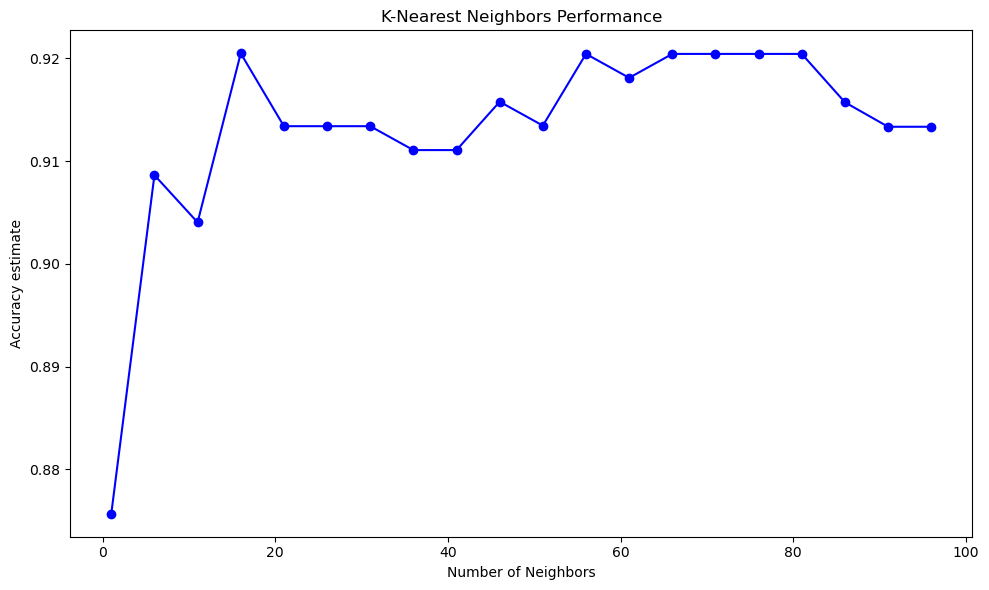

In [25]:
# Create the plot
plt.figure(figsize=(10, 6))

# Plot mean test scores with error bars
plt.plot(accuracies_grid['param_n_neighbors'], accuracies_grid['mean_test_score'], '-o', color='blue')

# Add labels and legend
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy estimate')
plt.title('K-Nearest Neighbors Performance')
plt.tight_layout()
plt.show()

We can **also** obtain the number of neighbours with the highest accuracy programmatically by accessing the `best_params_ attribute` of the fit GridSearchCV object. 

*Note*  it is still useful to visualize the results as we did above since this provides additional information on how the model performance varies.

In [26]:
cancer_tune_grid.best_params_

{'n_neighbors': 16}

Choosing 16 neighbors gives the highest cross-validation accuracy estimate at 92%. 

Remember, these accuracy estimates are approximations. Even though 16 neighbors shows the highest accuracy here, it doesn't guarantee the classifier is truly better with this setting. When selecting parameters, aim for values where:

- Accuracy is **roughly** optimal, suggesting the model will perform well.
- Nearby values (e.g., slightly higher or lower) don't significantly decrease accuracy, ensuring reliability.
- Training costs are manageable (e.g., avoid excessively large parameters that make predictions costly).

### Underfitting and Overfitting

As you've seen in the above graph, something unusual happens as the number of neighbors ($k$) increases. The cross-validation accuracy might start to drop when $k$ gets too large. This is because the model becomes too general and starts to "underfit" the data. By testing a wider range of $k$ values with `GridSearchCV`, you can see how accuracy changes from small values of $k$ up to nearly the total number of observations.

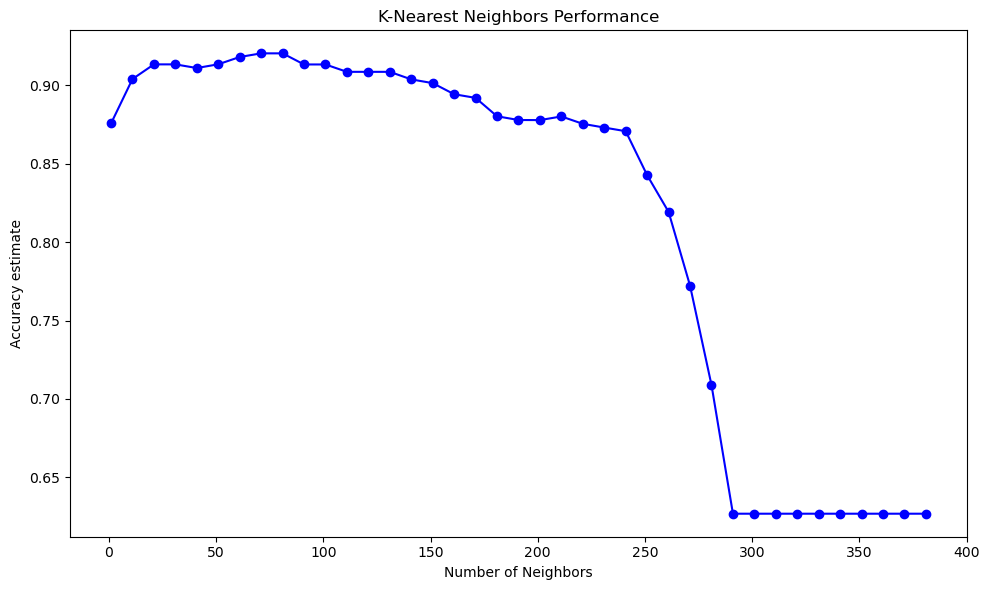

In [27]:
large_param_grid = {
    "n_neighbors": range(1, 385, 10),
}

large_cancer_tune_grid = GridSearchCV(
    estimator=knn,
    param_grid=large_param_grid,
    cv=10
)

large_cancer_tune_grid.fit(
    cancer_train[["perimeter_mean", "concavity_mean"]],
    cancer_train["diagnosis"]
)

large_accuracies_grid = pd.DataFrame(large_cancer_tune_grid.cv_results_)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot mean test scores with error bars
plt.plot(large_accuracies_grid['param_n_neighbors'], large_accuracies_grid['mean_test_score'], '-o', color='blue')

# Add labels and legend
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy estimate')
plt.title('K-Nearest Neighbors Performance')
plt.tight_layout()
plt.show()

As the number of neighbors $k$ increases, the classifier starts to average predictions over more distant points, smoothing the decision boundary and potentially leading to **underfitting**. This means the model becomes too simplistic and less sensitive to individual training examples, which might result in poor performance if the model doesn't capture the complexity of the data.

Conversely, with a very small $k$, each data point has a stronger influence, making the decision boundary more jagged and sensitive to noise in the training data. This can lead to **overfitting**, where the model becomes too tailored to the training set and performs poorly on new, unseen data. In the extreme case where  $k$ is 1, the model simply matches new observations to their nearest training example, which can cause significant variability in predictions based on the training data used.

📼 A video to better visualize underfitting and overfitting:

[![](./images/Underfitting&Overfitting.png)](https://www.youtube.com/watch?v=o3DztvnfAJg)

#### Overview of workflow

1. **Split the Data**: Use `train_test_split` to divide the data into training and test sets. Set `stratify` to the class label column to maintain class distribution. Set the test set aside.

2. **Define the Parameter Grid**: Specify the range of $k$ values to tune.

3. **Perform Grid Search**: Use `GridSearchCV` with a parameter grid to estimate accuracy for different $k$ values.

4. **Execute Grid Search**: Fit the `GridSearchCV` instance on the training data to find the best $k$.

5. **Select Optimal $k$**: Choose the $k$ value with high accuracy and stable performance across nearby values.

6. **Retrain the Model**: Create a new model with the best $k$ and fit it to the training data.

7. **Evaluate the Model**: Assess the model's accuracy on the test set using the `score` method.

### Conclusion

In this notebook, we worked through several steps to classify tumors as either benign or malignant using the Wisconsin Diagnostic Breast Cancer dataset and evaluate their performance. Here's a summary of what we covered:

1. **K-Nearest Neighbors Algorithm (KNN):** We implemented the KNN algorithm and evaluated its performance on a test dataset.

2. **Cross-Validation:** We used cross-validation to determine the optimal 
$k$ value for our classifier.

3. **Underfitting/Overfitting**: We explored how varying $k$ can lead to underfitting or overfitting, discussing the implications of choosing a large or small $k$.

We hope this notebook has provided a practical understanding of data classification, model evaluation, and the application of machine learning algorithms like KNN. Feel free to experiment further with the dataset or the code to enhance your learning!


### Install Packages and Import Dataset

In this notebook, we’ll be working with a data set from the `palmerpenguins` package. This dataset contains two variables—penguin bill (A bill is another term for a bird’s beak) and flipper length (In penguins, the flipper is their equivalent of a wing.), both in millimeters—to determine whether there are distinct types of penguins in our data.

In this case, we don’t have any labels or categories already given to us. That means no one has told us what group each data point belongs to. By looking at the features of the data, like patterns or similarities, we might be able to discover new species or create our own categories based on what we find in the data.

This dataset was obtained from [kaggle](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data)

In [1]:
import numpy as np
import pandas as pd
from sklearn import set_config
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [2]:
# Output dataframes instead of arrays
set_config(transform_output="pandas")

penguins = pd.read_csv("dataset/penguins.csv")
penguins

,bill_length_mm,flipper_length_mm
0,39.1,181
1,39.5,186
2,40.3,195
3,36.7,193
4,39.3,190
...,...,...
337,55.8,207
338,43.5,202
339,49.6,193
340,50.8,210


In [11]:
# Grabbing the minimum and maximum values for our features 
min_max_values = penguins.agg(['min', 'max'])
min_max_values

,bill_length_mm,flipper_length_mm
min,32.1,172
max,59.6,231


We will standardize our data so that prior to clustering to ensures that all features contribute equally to the distance calculations, preventing any single feature from dominating the results due to its scale.

> **Side note:**  
>  
> We will standardize our data prior to clustering to ensure that all features contribute equally to the distance calculations, preventing any single feature from dominating the results due to its scale. 
> 
> In clustering, distances between data points matter. For example, features like bill length (32.1 to 59.6 mm) and flipper length (172 to 231 mm) have different ranges, and without standardization, flipper length could dominate the analysis. Standardizing ensures both features contribute equally to the grouping process, which is critical when feature ranges differ significantly, but less important when interpretation matters.
>
> Recall, we also did this when we worked with KNN regression and classification, both of which rely on the same distance calculation!

In [7]:
#First, lets make a copy of the original data so that we don’t accidentally overwrite it while pre-processing.

penguins_copy = penguins.copy()

scaler = StandardScaler()
standardized_penguins = scaler.fit_transform(penguins_copy)

# Convert the standardized data back to a DataFrame
standardized_penguins = pd.DataFrame(standardized_penguins, columns=standardized_penguins.columns)

standardized_penguins


,bill_length_mm,flipper_length_mm
0,-0.884499,-1.418347
1,-0.811126,-1.062250
2,-0.664380,-0.421277
3,-1.324737,-0.563715
4,-0.847812,-0.777373
...,...,...
337,2.178824,0.433355
338,-0.077396,0.077258
339,1.041543,-0.563715
340,1.261662,0.647013


### Visualizing the Data

Now, let’s create a scatter plot to visualize the relationship between the two variables and see if we can detect subtypes or groups in our data set.

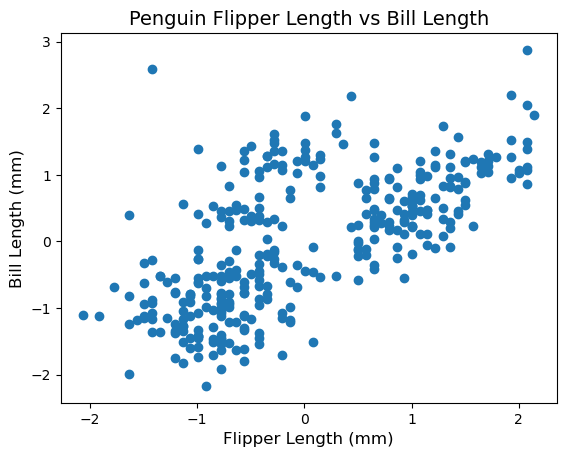

In [15]:
# Scatter plot for bill_length_mm vs flipper_length_mm
plt.scatter(standardized_penguins['flipper_length_mm'], standardized_penguins['bill_length_mm'])

# Adding labels and title
plt.title('Penguin Flipper Length vs Bill Length', fontsize=14)
plt.ylabel('Bill Length (mm)', fontsize=12)
plt.xlabel('Flipper Length (mm)', fontsize=12)

# Display the plot
plt.show()

Based on the visualization, we might suspect there are a few subtypes of penguins within our data set. We can see roughly 3 groups of observations, including:

1. a small flipper and bill length group,

2. a small flipper length, but large bill length group, and

3. a large flipper and bill length group.

Data visualization helps us see patterns with a few variables, but as the number of variables increases, it becomes harder to find groups. To systematically group data, we use clustering algorithms. This notebook focuses on **K-means clustering** and the **Elbow method** to choose the number of clusters, which effectively organizes data into groups.

### What is K-means Clustering?

K-means clustering is a way to group data points into **K** different groups, based on how similar or close the points are to each other. The number **K** is the number of clusters you want to find in the data. The main goal of K-means is to organize the data into clusters where the points in each cluster are close together, while points in different clusters are far apart.

In order to find these clusters, K-means performs two main steps over and over:

1. **Center Update**: It recalculates the center of each cluster by finding the average location of all the points in the cluster. The center is the "heart" of the cluster and represents the average point of that group.

2. **Label Update**: Each data point is then assigned to the nearest center (cluster). This step makes sure that every point belongs to the group with the closest center.

These two steps repeat until the centers stop moving and the points stay in the same groups. By doing this, K-means finds the best grouping of points, minimizing the distance between each point and its cluster center. This process ensures that similar points are grouped together, forming distinct clusters in the data.

#### How Does K-means Work?


To perform K-means clustering in Python, it follows a similar workflow to classification and regression tasks. 

##### **Step 1:** Create the K-means Model
To indicate that we are performing K-means clustering, we will create a KMeans model object. It takes at least one argument: the number of clusters `n_clusters`, **which we set to 5 randomly** (We'll come back to this.)

Note that the K-means algorithm uses a random initialization of assignments, we need to set a random state so that our clustering will be reproducible.

In [12]:
# Perform K-means clustering
kmeans = KMeans(n_clusters=5, random_state=0)
clusters = kmeans.fit(standardized_penguins)

/Users/juliagallucci/miniconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


##### **Step 2:** Cluster visualization

The KMeans object contains useful information for visualizing and evaluating clusters. To start, you can visualize the clusters with a colored scatter plot. First, add the cluster assignments to your original penguins DataFrame using the `labels_` attribute of the KMeans object. This will help you see how the data points are grouped.

In [13]:
# Create a copy of the DataFrame for clustering and modification
standardized_penguins_with_clusters = standardized_penguins.copy()

# Add cluster labels to the copied DataFrame
standardized_penguins_with_clusters['Cluster'] = clusters.labels_

# Display the updated DataFrame with the 'Cluster' column
standardized_penguins_with_clusters

,bill_length_mm,flipper_length_mm,Cluster
0,-0.884499,-1.418347,1
1,-0.811126,-1.062250,1
2,-0.664380,-0.421277,3
3,-1.324737,-0.563715,1
4,-0.847812,-0.777373,1
...,...,...,...
337,2.178824,0.433355,0
338,-0.077396,0.077258,3
339,1.041543,-0.563715,0
340,1.261662,0.647013,0


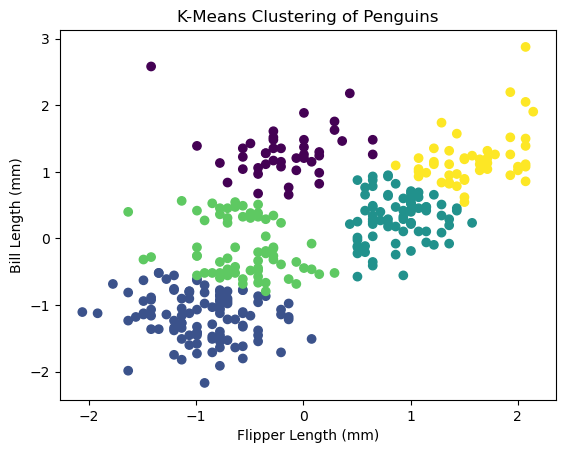

In [14]:
# Plot the clusters
plt.scatter(standardized_penguins_with_clusters['flipper_length_mm'], standardized_penguins_with_clusters['bill_length_mm'], c=standardized_penguins_with_clusters['Cluster'])
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Bill Length (mm)')
plt.title('K-Means Clustering of Penguins')
plt.show()


Great! Now we know how to Create the K-means Model and Visualize it, but...

###  How do we Choose the **Optimal** Number of Clusters (K)?

Mathematically, the WSSD (Within-Cluster Sum of Squared Distances) formula is:

$$
\text{WSSD} = \sum_{i=1}^{k} \sum_{x \in C_i} \left( \| x - \mu_i \|^2 \right)
$$

Where:
- $k$ is the number of clusters.
- $ C_i $ is the set of points in cluster $ i $.
- $ \mu_i $ is the center (mean) of cluster $ i $.
- $ \| x - \mu_i \|^2 $ is the squared distance between a data point $ x $ and the center $ \mu_i $.

To find the best number of clusters, we use the **elbow method**. This involves plotting the total WSSD against different values of $k$ and looking for an “elbow”—the point where increasing the number of clusters no longer leads to a significant reduction in WSSD.

#### Thankfully...

we don’t need to manually calculate the WSSD using the formula. In scikit-learn, the total WSSD is already stored in the `.inertia_` attribute of the KMeans object.

In [16]:
clusters.inertia_

91.46939830604309

To calculate the total WSSD for different values of $k$, we’re going to loop through several values of $k$ (the number of clusters) and run K-means for each one. We'll store the WSSD results for each $k$ in a DataFrame so we can compare them later.

In [24]:
## Initialize an empty DataFrame to store the k and WSSD values
penguin_clust_ks = pd.DataFrame(columns=["k", "wssd"])

# Loop through values of k from 1 to 10
for k in range(1, 11):
    # Initialize K-means clustering model
    elbow_kmeans = KMeans(n_clusters=k, random_state=0)
    # Fit the initialized model to our data
    elbow_kmeans.fit(standardized_penguins)

    # Append the current k and inertia (WSSD) to the DataFrame
    penguin_clust_ks = penguin_clust_ks.append({"k": k, "wssd": elbow_kmeans.inertia_}, ignore_index=True)

# Display the DataFrame
penguin_clust_ks


/Users/juliagallucci/miniconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/var/folders/9y/zgnxp44x71g645k284kc5j_h0000gn/T/ipykernel_9072/1675933650.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  penguin_clust_ks = penguin_clust_ks.append({"k": k, "wssd": elbow_kmeans.inertia_}, ignore_index=True)
/Users/juliagallucci/miniconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/var/folders/9y/zgnxp44x71g645k284kc5j_h0000gn/T/ipykernel_9072/1675933650.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a 

,k,wssd
0,1.0,684.000000
1,2.0,247.016625
2,3.0,157.815322
3,4.0,118.770529
4,5.0,91.469398
5,6.0,78.473570
6,7.0,69.222923
7,8.0,57.849867
8,9.0,52.598413
9,10.0,48.330547


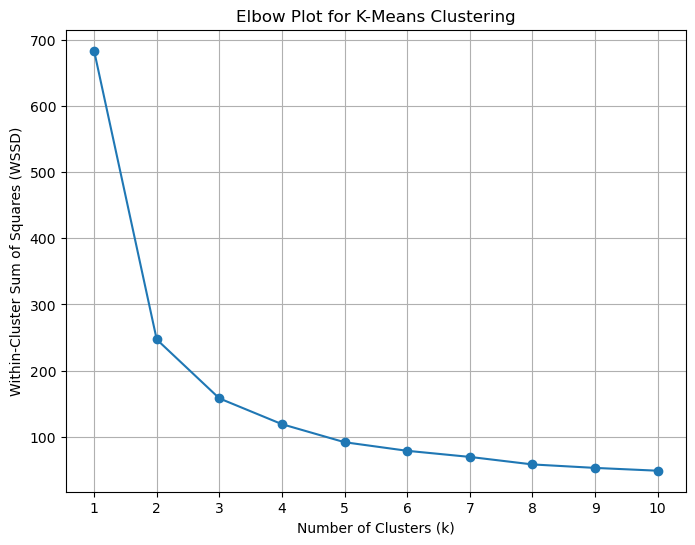

In [23]:
# Create the elbow plot
plt.figure(figsize=(8, 6))
plt.plot(penguin_clust_ks['k'], penguin_clust_ks['wssd'], marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WSSD)')
plt.title('Elbow Plot for K-Means Clustering')
plt.xticks(penguin_clust_ks['k'])  # Optional: to ensure all k values are shown on the x-axis
plt.grid(True)
plt.show()


Three clusters appear to be the best choice because the plot shows a clear "elbow" at this point. This means that adding more clusters beyond three doesn't significantly reduce the WSSD, indicating that three clusters provide a good balance between capturing the structure in the data and minimizing the WSSD without over-complicating the model.

Feel free to scroll up and change the number of clusters in the code from three to any other value. Then, re-run the rest of the code to see how different numbers of clusters affect the results.

### Conclusion

In this notebook, we worked through exploratory analyses to identify meaningful subgroups (or clusters) in the data. Here's a summary of what we covered:

1. **Scaling**: We identify when it is necessary to scale variables before clustering.
2. **K-means clustering:** We implemented k-means clustering 
3. **Visualization:** We visualized the output of K-means clustering using a colored scatter plot.
4. **Elbow method:** We used the elbow method to choose the number of clusters for K-means. 


We hope this notebook has provided a practical understanding of data clustering,  and the application of machine learning algorithms like k-means. Feel free to experiment further with the dataset or the code to enhance your learning!

### Install Packages and Import Dataset

In this notebook, we’ll be working with a data set of real estate transactions in Sacramento, California. This dataset contains several features regarding property details, including location, size, type, and price..

Each row in the dataset represents a listing, with various property details:

- **City:** The city where the property is located.
- **Zip:** The postal code for the property’s location.
- **Beds:** The number of bedrooms in the property.
- **Baths:** The number of bathrooms in the property.
- **Sqft:** The square footage of the property.
- **Type:** The type of property (e.g., Residential).
- **Latitude:** The latitude coordinate of the property.
- **Longitude:** The longitude coordinate of the property.

The target column is **Price**, which we will try to predict based on the other features in the dataset.

This dataset was obtained from [spatialkey](https://support.spatialkey.com/spatialkey-sample-csv-data/)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import set_config
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Our question: **Can we use the size of a house in the Sacramento, CA area to predict its sale price?**

In [2]:
# Output dataframes instead of arrays
set_config(transform_output="pandas")

sacramento = pd.read_csv("dataset/sacramento.csv")
sacramento

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,1005 MORENO WAY,SACRAMENTO,95838,CA,3,2,1410,Residential,Fri May 16 00:00:00 EDT 2008,180000,38.646206,-121.442767
1,10105 MONTE VALLO CT,SACRAMENTO,95827,CA,4,2,1578,Residential,Fri May 16 00:00:00 EDT 2008,190000,38.573917,-121.316916
2,10133 NEBBIOLO CT,ELK GROVE,95624,CA,4,3,2096,Residential,Fri May 16 00:00:00 EDT 2008,289000,38.391085,-121.347231
3,10165 LOFTON WAY,ELK GROVE,95757,CA,3,2,1540,Residential,Fri May 16 00:00:00 EDT 2008,266510,38.387708,-121.436522
4,10254 JULIANA WAY,SACRAMENTO,95827,CA,4,2,2484,Residential,Fri May 16 00:00:00 EDT 2008,331200,38.568030,-121.309966
...,...,...,...,...,...,...,...,...,...,...,...,...
808,9507 SEA CLIFF WAY,ELK GROVE,95758,CA,4,2,2056,Residential,Wed May 21 00:00:00 EDT 2008,285000,38.410992,-121.479043
809,9570 HARVEST ROSE WAY,SACRAMENTO,95827,CA,5,3,2367,Residential,Wed May 21 00:00:00 EDT 2008,315537,38.555993,-121.340352
810,9723 TERRAPIN CT,ELK GROVE,95757,CA,4,3,2354,Residential,Wed May 21 00:00:00 EDT 2008,335750,38.403492,-121.430224
811,9837 CORTE DORADO CT,ELK GROVE,95624,CA,4,2,1616,Residential,Wed May 21 00:00:00 EDT 2008,227887,38.400676,-121.381010


This question guides our initial exploration: and after looking at the data, we can see that the columns in the data that we are interested in are 
- sq__ft (house size, in livable square feet)
-  price (house sale price, in US dollars (USD)). 

### Visualizing the Data

Now, let’s create a scatter plot to visualize the relationship between the predictor variable (**house size**) on the x-axis, and we place the response variable that we want to predict (**sale price**) on the y-axis.

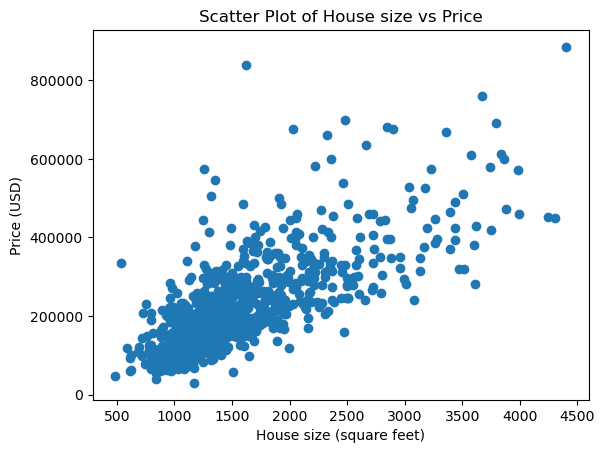

In [3]:
# Plot
plt.scatter(sacramento["sq__ft"], sacramento['price'])

# Add labels and legend
plt.xlabel("House size (square feet)")
plt.ylabel('Price (USD)')
plt.title('Scatter Plot of House size vs Price')
plt.show()

We can see that in Sacramento, CA, larger houses tend to have higher sale prices. This means we might be able to predict the sale price of a house we haven't sold yet based on its size. 

> **Note**:
> It's important to remember that we're not saying a bigger house **causes** a higher price; we're just observing that larger houses generally sell for more, so size can help us estimate the price. 
> We typically apply feature scaling for KNN regression to ensure all predictors contribute equally to distance calculations. However, since our model includes only a single predictor variable, scaling is unnecessary in this case.

### K-nearest neighbors regression

KNN regression is like K-Nearest Neighbors, but instead of predicting a category, it predicts a number. It looks at the closest `k` data points and then takes the average of their values to make the prediction. For example, if you want to predict a house price, KNN regression will look at the prices of the closest `k` houses and use their average as the predicted price.

Let's start with a small sample of the data to understand how K-nearest neighbors (KNN) works for regression. By using this small subset, we can illustrate the basics of KNN regression and how it predicts house sale prices before building and evaluating a full model.

To take a small random sample of size 30, we’ll use the `sample` method on the sacramento data frame, specifying that we want to select n=30 rows.

In [4]:
#set seed for reproducibility
np.random.seed(10)
small_sacramento = sacramento.sample(n=30)
small_sacramento

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
486,7540 HICKORY AVE,ORANGEVALE,95662,CA,3,1,1456,Residential,Thu May 15 00:00:00 EDT 2008,225000,38.703056,-121.235221
399,9013 CASALS ST,SACRAMENTO,95826,CA,2,1,795,Condo,Mon May 19 00:00:00 EDT 2008,126960,38.557045,-121.371670
233,12901 FURLONG DR,WILTON,95693,CA,5,3,3788,Residential,Mon May 19 00:00:00 EDT 2008,691659,38.413535,-121.188211
408,9474 VILLAGE TREE DR,ELK GROVE,95758,CA,4,2,1776,Residential,Mon May 19 00:00:00 EDT 2008,210000,38.413947,-121.408276
549,2901 PINTAIL WAY,ELK GROVE,95757,CA,4,3,3070,Residential,Tue May 20 00:00:00 EDT 2008,495000,38.398488,-121.473424
43,191 BARNHART CIR,SACRAMENTO,95835,CA,4,2,2605,Residential,Fri May 16 00:00:00 EDT 2008,257200,38.675594,-121.515878
181,8316 NORTHAM DR,ANTELOPE,95843,CA,3,2,1235,Residential,Fri May 16 00:00:00 EDT 2008,246544,38.720767,-121.376678
250,2130 CATHERWOOD WAY,SACRAMENTO,95835,CA,3,2,1424,Residential,Mon May 19 00:00:00 EDT 2008,251000,38.675506,-121.510987
140,620 KESWICK CT,GRANITE BAY,95746,CA,4,3,2356,Residential,Fri May 16 00:00:00 EDT 2008,600000,38.732096,-121.219142
392,8593 DERLIN WAY,SACRAMENTO,95823,CA,3,2,1436,Residential,Mon May 19 00:00:00 EDT 2008,180000,38.447585,-121.426627


To estimate the sale price of a 2,000 square-foot house in Sacramento when we don't have exact data for that size, we can use KNN.

1. **Find Similar Houses**: Identify houses in the dataset that are closest in size to 2,000 square feet. This involves calculating the distance between the 2,000 square-foot house and the sizes of other houses in the dataset.

2. **Select Neighbors**: Choose a small number of these closest houses (the "neighbors"). The number of neighbors is a parameter you can set for KNN.

3. **Average Price**: Calculate the average sale price of these neighbors. This average will give you an estimate of the price for the 2,000 square-foot house.

By using this approach, you can make an informed offer based on the sale prices of similar houses in the dataset, even though you don’t have an exact match for the 2,000 square-foot size.

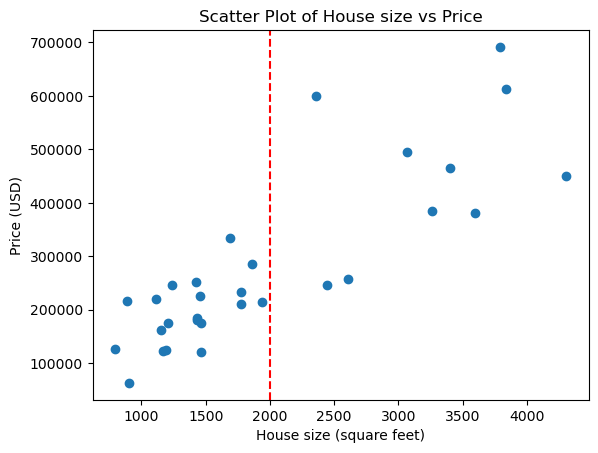

In [5]:
# Plot
plt.scatter(small_sacramento["sq__ft"], small_sacramento['price'])

# Add a vertical line at 2,000 square feet
plt.axvline(x=2000, color='red', linestyle='--', label='2000 sqft')

# Add labels and legend
plt.xlabel("House size (square feet)")
plt.ylabel('Price (USD)')
plt.title('Scatter Plot of House size vs Price')

plt.show()

We will employ the same idea as our prior notebooks, and use the neighboring points to the new point of interest to predict what its sale price might be. 

For the example here we find and label the 5 nearest neighbors to our observation of a house that is 2,000 square feet.

In [6]:
# Calculate the absolute difference between 2000 and the square footage of each house
small_sacramento["dist"] = (2000 - small_sacramento["sq__ft"]).abs()

# Find the 5 rows with the smallest distances (closest to 2000 square feet)
nearest_neighbors = small_sacramento.nsmallest(5, "dist")

# Display the 5 nearest neighbors
nearest_neighbors

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude,dist
280,3228 I ST,SACRAMENTO,95816,CA,4,3,1939,Residential,Mon May 19 00:00:00 EDT 2008,215000,38.573844,-121.462839,61
197,8986 HAFLINGER WAY,ELK GROVE,95757,CA,3,2,1857,Residential,Fri May 16 00:00:00 EDT 2008,285000,38.397923,-121.450219,143
408,9474 VILLAGE TREE DR,ELK GROVE,95758,CA,4,2,1776,Residential,Mon May 19 00:00:00 EDT 2008,210000,38.413947,-121.408276,224
599,5340 BIRK WAY,SACRAMENTO,95835,CA,3,2,1776,Residential,Tue May 20 00:00:00 EDT 2008,234000,38.672495,-121.515251,224
786,8025 PEERLESS AVE,ORANGEVALE,95662,CA,2,1,1690,Residential,Wed May 21 00:00:00 EDT 2008,334150,38.711470,-121.216214,310


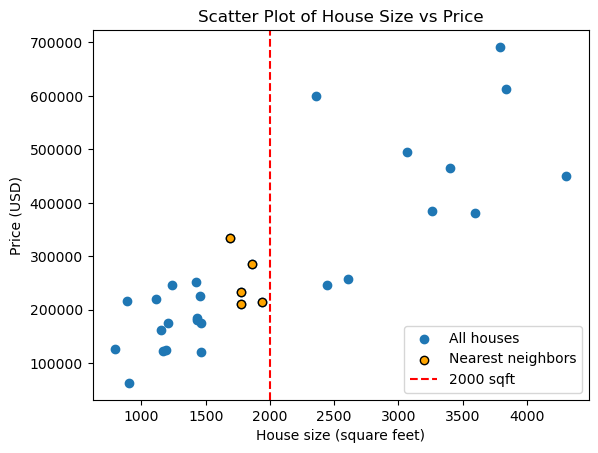

In [7]:
# Scatter plot
plt.scatter(small_sacramento["sq__ft"], small_sacramento['price'], label='All houses')

# Plot nearest neighbors in orange
plt.scatter(nearest_neighbors["sq__ft"], nearest_neighbors['price'], color='orange', label='Nearest neighbors', edgecolor='black')

# Add a vertical line at 2,000 square feet
plt.axvline(x=2000, color='red', linestyle='--', label='2000 sqft')

# Add labels, title, and legend
plt.xlabel("House size (square feet)")
plt.ylabel('Price (USD)')
plt.title('Scatter Plot of House Size vs Price')
plt.legend()

We can then take the mean (or average) of these 5 values as our predicted value,

In [8]:
prediction = nearest_neighbors["price"].mean()
prediction

255630.0

Similar to KNN classification, we have some remaining steps. which $K$ do we choose, and is our model any good at making predictions?

### Training, evaluating, and tuning the model

Step 1. Split the dataset into test and train

In [9]:
sacramento_train, sacramento_test = train_test_split(
    sacramento, train_size=0.75, random_state=42
)

In [10]:
sacramento_train.shape

(609, 12)

In [11]:
sacramento_test.shape

(204, 12)

Step 2. Cross-validation

In KNN regression, to evaluate how well the model predicts the response variable, we use root mean square prediction error (RMSPE). The formula for calculating RMSPE is:

$$
 \text{RMSPE} = \sqrt{\frac{1}{n}\sum\limits_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

where:
- $ y_i $ is the true value of the response variable,
- $ \hat{y}_i $ is the predicted value from the model,
- $ n $ is the number of observations.

RMSPE measures how much our predictions deviate from the actual values. It gives us an idea of how close our predictions are to the real outcomes.

Here is the above mathematical notation in python:

In [13]:
import math

def rmspe(y_true, y_pred):
    """
    Calculate Root Mean Squared Prediction Error (RMSPE) # or also called RMSE: Root Mean Squared Error
    
    Parameters:
    y_true: list-like, actual values
    y_pred: list-like, predicted values
    
    Returns:
    float: RMSPE value
    """
    n = len(y_true)
    squared_errors = []

    for i in range(n):
        error = y_true[i] - y_pred[i]
        squared_errors.append(error ** 2)

    mean_squared_error = sum(squared_errors) / n

    # Calculate the square root of the mean squared error
    rmspe_value = math.sqrt(mean_squared_error)
    
    return rmspe_value

### Let's Begin KNN Regressor Training:

Let's see if there is any correlation between square footage and price.

In [14]:
# Step 1: Split training data into X (predictor) and Y (response)
X_train = sacramento_train[["sq__ft"]]
y_train = sacramento_train["price"]

# Step 2: Initialize K-NN regressor
knn_regressor = KNeighborsRegressor()

# Step 3: Define parameter grid for GridSearchCV
param_grid = {
    "n_neighbors": range(1, 201, 3),        # But wait...? What is this?
}

# Step 4: Initialize and fit GridSearchCV
sacr_gridsearch = GridSearchCV(
    estimator=knn_regressor,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

sacr_gridsearch.fit(X_train, y_train)

# Step 5: Retrieve and format results
results = pd.DataFrame(sacr_gridsearch.cv_results_)     # After fitting the model, we extract the cross-validation results using `cv_results_`. This output includes various metrics and parameters tested during the cross-validation process.
results = (
    results[[
        "param_n_neighbors",
        "mean_test_score"
    ]]
    .rename(columns={"param_n_neighbors": "n_neighbors"})
) # we specify the scoring metric as "neg_root_mean_squared_error" to evaluate the model performance based on RMSPE.

print(results)

   n_neighbors  mean_test_score
0            1   -115096.457636
1            4    -93675.812662
2            7    -90334.266322
3           10    -88585.351601
4           13    -87276.736534
..         ...              ...
62         187    -96196.284147
63         190    -96501.008677
64         193    -96773.410839
65         196    -97024.993747
66         199    -97253.073041

[67 rows x 2 columns]


>
> ##### But Wait...?
>
> *"Why are they using 1-200? How do they know 200 is enough?"*
>   - They don't! That's just an intuition, they could've done 20. They are testing values from 1 to 200 because different datasets and problems might require different optimal values for n_neighbors.
>
> *"Well why are they checking every 3 steps? Why not all of them?"*
>   - The step size of 3 is used to reduce the number of computations, ensuring a balance between exploring a wide range of values and not taking too long by testing every possible value between 1 and 200.
>

Next, we can run cross-validation by calling the fit method on our GridSearchCV object (sacr_gridsearch).

>
> #### Note:
>
> The use of double brackets sacramento_train[["sqft"]] to ensure the input features are in a DataFrame format. 
> This is important because scikit-learn often works better with DataFrames rather than Series for input features. 
>
 
Lastly, we extract relevant columns (e.g., mean test scores and parameter values) based on the 5-fold cross-validation.

In [15]:
results

,n_neighbors,mean_test_score
0,1,-115096.457636
1,4,-93675.812662
2,7,-90334.266322
3,10,-88585.351601
4,13,-87276.736534
...,...,...
62,187,-96196.284147
63,190,-96501.008677
64,193,-96773.410839
65,196,-97024.993747


In the `results` DataFrame, the `n_neighbors` column shows the values of `n_neighbors`, and the `mean_test_score` column displays the RMSPE values estimated via cross-validation. However, RMSPE is always be nonnegative because it measures **how far off the model’s predictions are from the actual values**—the difference, like a distance, can’t be negative.

Scikit-learn was built to always try to **maximize** scores. Since RMSPE is a metric where **lower is better**, it automatically flips it to a negative value (that’s why there’s a `"neg_"` prefix). This lets Scikit-learn treat it like a score to maximize, even though we are really trying to minimize the error. To get the actual RMSPE values, we need to convert these negative values back to positive by taking their absolute values.

In [16]:
results["mean_test_score"] = -results["mean_test_score"]
# could also code this as results["mean_test_score"] = results["mean_test_score"].abs()
results

,n_neighbors,mean_test_score
0,1,115096.457636
1,4,93675.812662
2,7,90334.266322
3,10,88585.351601
4,13,87276.736534
...,...,...
62,187,96196.284147
63,190,96501.008677
64,193,96773.410839
65,196,97024.993747


In the updated `results` DataFrame, the `mean_test_score` now correctly reflects the RMSPE values for different numbers of neighbors. 

We can visualize how RMSPE changes with different numbers of neighbors. By finding the minimum RMSPE, we can determine the best number of neighbors for our model. In this case, the lowest RMSPE occurs when the number of neighbors is 19.

In [17]:
results.nsmallest(1, 'mean_test_score')

,n_neighbors,mean_test_score
6,19,86621.515595


In [18]:
sacr_gridsearch.best_params_

{'n_neighbors': 19}

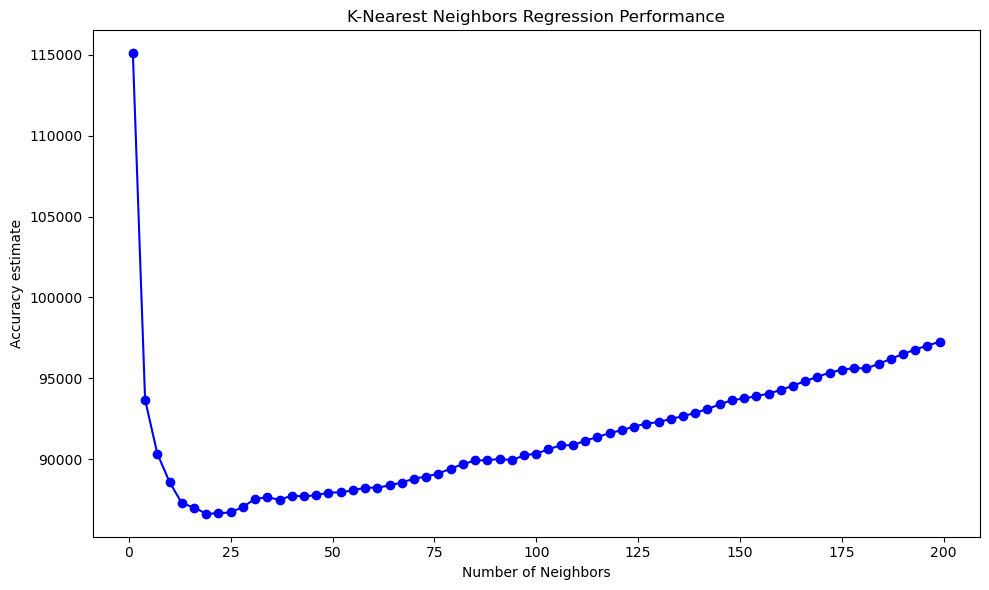

In [19]:
# Create the plot
plt.figure(figsize=(10, 6))

# Plot mean test scores with error bars
plt.plot(results['n_neighbors'], results['mean_test_score'], '-o', color='blue')

# Add labels and legend
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy estimate')
plt.title('K-Nearest Neighbors Regression Performance')
plt.tight_layout()
plt.show()

### Model Evaluation

To evaluate how well our model predicts unseen data, we'll check its RMSPE on the test set. First, we need to retrain the K-NN regression model using 25 neighbors on the full training data. Scikit-learn handles this automatically when using `GridSearchCV`. To make predictions, we use the `predict` method from the fitted `GridSearchCV` object. We then calculate the RMSPE by computing the mean squared error with `mean_squared_error` and taking the square root. We use this method instead of the `score` method because `KNeighborsRegressor` uses a different default metric than RMSPE.

In [20]:
# Make predictions on the test set
sacramento_test["predicted"] = sacr_gridsearch.predict(sacramento_test[["sq__ft"]])

# Calculate RMSPE
rmspe = mean_squared_error(
    y_true=sacramento_test["price"],
    y_pred=sacramento_test["predicted"]
)**0.5

rmspe

74240.70943389146

Our final model’s test error as assessed by RMSPE is $74,240

> **Note:**
>
> The RMSPE is in the same units as the response variable, so for new observations, we expect prediction errors to be around $74,240. In this case, it’s not negligible and could significantly impact a home buyer's budget, influencing their decision to make an offer on a house.

If we wanted to also calculate and display the R2 (coefficient of determination) for the test set, you can use the `r2_score` function from Scikit-learn in the same way. 

In [21]:
# Calculate R² 
r2 = r2_score( 
y_true=sacramento_test["price"], y_pred=sacramento_test["predicted"] 
)

r2

0.49526130381694955

This means our predictor variable (square footage) explains 49.5% of the variance in housing prices.

We can visualize the predictions of our final model across various house sizes in Sacramento. 

We can overlay a prediction line on a scatter plot of the original housing price data to qualitatively assess how well the model fits the data. 

/Users/juliagallucci/miniconda3/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


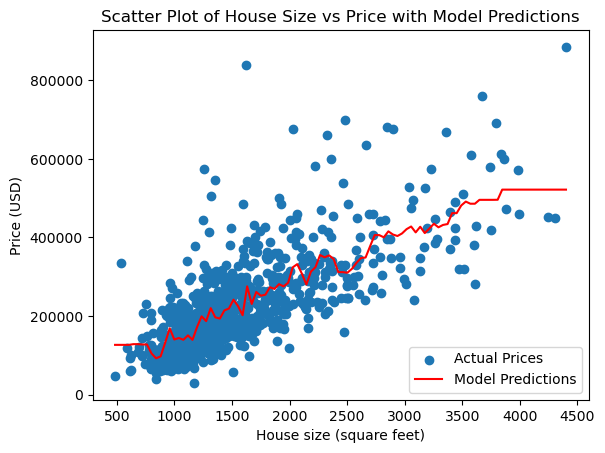

In [22]:
# Generate a range of house sizes for prediction
sizes = np.linspace(sacramento["sq__ft"].min(), sacramento["sq__ft"].max(), 100).reshape(-1, 1)

# Predict house prices for these sizes using the best model from GridSearchCV
predicted_prices = sacr_gridsearch.predict(sizes)

# Plot the original data
plt.scatter(sacramento["sq__ft"], sacramento["price"], label="Actual Prices")

# Plot the model predictions as a line
plt.plot(sizes, predicted_prices, color='red', label="Model Predictions")

# Add labels and legend
plt.xlabel("House size (square feet)")
plt.ylabel("Price (USD)")
plt.title("Scatter Plot of House Size vs Price with Model Predictions")
plt.legend()
plt.show();

Don't worry about the details of this plot. This is simply depicting the predicted values of house price (red line) for the final KNN regression model.



### Conclusion

In this notebook, we worked through several steps to predict housing prices using square feet using a data set of 813 real estate transactions in Sacramento, California. Here's a summary of what we covered:

1. **K-Nearest Neighbors Regression (KNN):** We implemented the KNN regression and evaluated its performance on a test dataset.

2. **Cross-Validation:** We used cross-validation to determine the optimal $k$ value for our model.


We hope this notebook has provided a practical understanding of data regression, model evaluation, and the application of machine learning algorithms like KNN. Feel free to experiment further with the dataset or the code to enhance your learning!

### Install Packages and Import Dataset

We’re continuing to work with the same dataset of 813 real estate transactions in Sacramento, California, which includes features like property location, size, and type. The target remains Price, which we’ll aim to predict based on these features.

This dataset was obtained from [spatialkey](https://support.spatialkey.com/spatialkey-sample-csv-data/)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score
from sklearn import set_config

# Output dataframes instead of arrays
set_config(transform_output="pandas")

KNN regression has its benefits—it’s simple to understand and can capture complex, nonlinear relationships in data. It works well when the data has patterns that are best explained by nearby neighbors. However, KNN regression also has its downsides. It struggles to make predictions for values outside the range of the training data, meaning it can’t effectively handle cases where the target variable extends beyond what’s been observed. Additionally, as the dataset grows larger, KNN becomes computationally slower since it has to calculate distances for every new prediction.
 
Because of these limitations, especially when we need to generalize beyond the training data or handle larger datasets more efficiently, we often turn to linear regression as an alternative. Linear regression offers a more scalable approach and provides a way to make predictions across a wider range of values.

This notebook will start with simple linear regression, which uses one predictor and one outcome, and later moves to multivariable linear regression.

### Well... what is linear regression then?

Linear regression is a method to find the best straight line that shows the relationship between two things. For example, if you have data about how much time students spend studying and their test scores, linear regression will help you draw a line to show how study time affects scores. The line helps us see the overall pattern—students who study more tend to get better scores—and allows us to predict test scores based on study time. It’s called "linear" because it shows a straight-line relationship between the two things.

![linear regression](./images/linear_regression.gif)

This method can be applied to other examples too, like the housing data we’re using, where linear regression helps predict house prices based on features like size or location.

#### Our question is predictive: 
**Can we use the size of a house in the Sacramento, CA area to predict its sale price?**

The equation for the straight line is:

$$
\text{House sale price} = b_0 + b_1 \times (\text{house size})
$$

where:

- $ b_0 $ is the price when the house size is 0 (the intercept).
- $ b_1 $ is how much the price increases for each unit increase in house size (the slope).

Using data to find the line of best fit means finding the coefficients $ b_0 $ and $ b_1 $, which define the line. You can think of $ b_0 $ as the base price and $ b_1 $ as the price increase per square foot. 

In [2]:
sacramento = pd.read_csv("dataset/sacramento.csv")
sacramento

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,1005 MORENO WAY,SACRAMENTO,95838,CA,3,2,1410,Residential,Fri May 16 00:00:00 EDT 2008,180000,38.646206,-121.442767
1,10105 MONTE VALLO CT,SACRAMENTO,95827,CA,4,2,1578,Residential,Fri May 16 00:00:00 EDT 2008,190000,38.573917,-121.316916
2,10133 NEBBIOLO CT,ELK GROVE,95624,CA,4,3,2096,Residential,Fri May 16 00:00:00 EDT 2008,289000,38.391085,-121.347231
3,10165 LOFTON WAY,ELK GROVE,95757,CA,3,2,1540,Residential,Fri May 16 00:00:00 EDT 2008,266510,38.387708,-121.436522
4,10254 JULIANA WAY,SACRAMENTO,95827,CA,4,2,2484,Residential,Fri May 16 00:00:00 EDT 2008,331200,38.568030,-121.309966
...,...,...,...,...,...,...,...,...,...,...,...,...
808,9507 SEA CLIFF WAY,ELK GROVE,95758,CA,4,2,2056,Residential,Wed May 21 00:00:00 EDT 2008,285000,38.410992,-121.479043
809,9570 HARVEST ROSE WAY,SACRAMENTO,95827,CA,5,3,2367,Residential,Wed May 21 00:00:00 EDT 2008,315537,38.555993,-121.340352
810,9723 TERRAPIN CT,ELK GROVE,95757,CA,4,3,2354,Residential,Wed May 21 00:00:00 EDT 2008,335750,38.403492,-121.430224
811,9837 CORTE DORADO CT,ELK GROVE,95624,CA,4,2,1616,Residential,Wed May 21 00:00:00 EDT 2008,227887,38.400676,-121.381010


This question guides our initial exploration: the columns in the data that we are interested in are 
- **sq__ft** (house size, in livable square feet)
-  **price** (house sale price, in US dollars (USD)). 

### How do we perform it?

We can perform simple linear regression in Python using scikit-learn much like we did for KNN regression. Instead of using a `KNeighborsRegressor` model, we create a `LinearRegression` model. Unlike KNN, we don't need to pick a $K$ value or use cross-validation to fine-tune the model.

Here's how we can predict house sale prices based on house size using simple linear regression with the full Sacramento real estate dataset.

### Training, evaluating, and tuning the model

#### **Step 1:** Split the dataset into test and train.

> **Note**: 
>
> Even though we’re using a different model, like linear regression, that doesn’t mean cross-validation goes away. Cross-validation is still useful and can be applied to various models, ensuring they perform well on unseen data by testing on multiple subsets. For more information on this please take a look at [classification_2.ipynb](./Classification-2.ipynb).

In [3]:
# Split the sacramento dataset into 75% training data and 25% test data
sacramento_train, sacramento_test = train_test_split(
    sacramento, train_size=0.75, random_state=42
)

#### **Step 2:** fit the linear regression model.

Here, we extract the slope of the line via the `coef_[0]` property, as well as the intercept of the line via the `intercept_` property.

In [4]:
# fit the linear regression model
lm = LinearRegression()
lm.fit(
   sacramento_train[["sq__ft"]],  # A single-column data frame (square footage)
   sacramento_train["price"]  # A series (house prices)
)

# Make a dataframe containing b_1 (slope) and b_0 (intercept) coefficients
pd.DataFrame({"slope": [lm.coef_[0]], "intercept": [lm.intercept_]})

   # lm.coef_[0] gives the slope b_1 (change in price per unit change in square footage)
   # lm.intercept_ gives the intercept b_0 (the predicted price when square footage is 0)

,slope,intercept
0,139.614833,7069.127004


Our coefficients are:

- Intercept ($b_0$): 7,069
- Slope ($b_1$): 139

This means the equation of the line of best fit is:

$$
\text{House sale price} = 7,069 + 139 \times (\text{house size})
$$

**So for each additional square foot of house size, the price increases by $139.**

#### **Step 3.** Finally, we predict on the test data set to assess how well our model does.

In [5]:
# make predictions
sacramento_test["predicted"] = lm.predict(sacramento_test[["sq__ft"]])

# calculate RMSPE
RMSPE = mean_squared_error(
    y_true=sacramento_test["price"],
    y_pred=sacramento_test["predicted"]
)**(1/2)

RMSPE

72549.85422128305

In [6]:
# Calculate R² 
r2 = r2_score( 
y_true=sacramento_test["price"], y_pred=sacramento_test["predicted"] 
)

r2

0.5179906495015956

Our final model's test error, measured by RMSPE, is $72,549. Since this is in US Dollars, it tells us how far off our predictions are on average. But does that make the model "good" at predicting house prices based on home size? That depends on how precise you need the predictions to be for your purpose! 

For example, a real estate investor dealing with multimillion-dollar properties might not mind this level of error, but for a first-time homebuyer with a 300,000 budget, being off by $72,549 could be a big deal.

To visualize the simple linear regression model, we can plot the predicted house sale prices across all possible house sizes. Since the model is a straight line, we only need to calculate the predicted prices at the smallest and largest house sizes, then draw a line between them. By overlaying this line on a scatter plot of the actual housing prices, we can visually check how well the model fits the data.

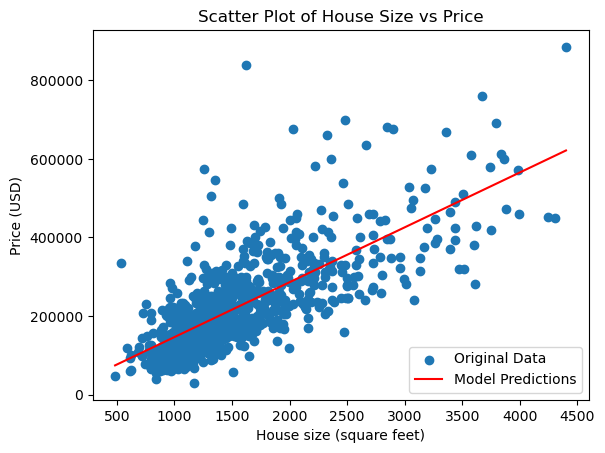

In [7]:
# This line calculates the minimum and maximum values of the "sq__ft" column in the sacramento dataset.
sqft_prediction_grid = sacramento[["sq__ft"]].agg(["min", "max"])

# Uses the linear model to predict prices for the min and max square footage values.
sqft_prediction_grid["predicted"] = lm.predict(sqft_prediction_grid)

# Plot the original data
plt.scatter(sacramento["sq__ft"], sacramento["price"], label='Original Data')

# Plot the model predictions as a line
plt.plot(sqft_prediction_grid["sq__ft"], sqft_prediction_grid["predicted"], color='red', label='Model Predictions')

# Add labels and legend
plt.xlabel('House size (square feet)')
plt.ylabel('Price (USD)')
plt.title('Scatter Plot of House Size vs Price')
plt.legend()

# Show the plot
plt.show()

Don't worry about the details of this plot. This is simply depicting the predicted values of house price (red line) for the final linear regression model.



### Cross-validation

Now, lets look at how we can implement cross-validation for linear regression. Using cross-validation provides a more reliable and comprehensive evaluation of your model's performance compared to a single train-test split!

To perform 5-fold cross-validation in Python using `scikit-learn`, we need to follow these steps:
1. Set cv=5 for 5 folds.
2. Provide the predictors and response as X and y.
3. Use the `cross_validate` function from scikit-learn.
4. Convert the results into a pandas DataFrame for better visualization.


In [8]:
returned_dictionary = cross_validate(
    estimator=lm,
    cv=5,    # setting up the cross validation number
    X= sacramento[["sq__ft"]],
    y= sacramento["price"],
    scoring="neg_root_mean_squared_error" #or scoring="r2"
)

cv_5_df = pd.DataFrame(returned_dictionary)    # Converting it to pandas DataFrame

cv_5_df


,fit_time,score_time,test_score
0,0.004467,0.000939,-81369.919847
1,0.001366,0.001184,-97590.236340
2,0.001619,0.000949,-61790.733828
3,0.001132,0.000649,-92026.283010
4,0.002873,0.000657,-75474.947490


`test_score` column, displays the negative Root Mean Squared Prediction Error (RMSPE) values estimated during the cross-validation process.

To obtain the actual root mean squared prediction error values (the nonnegative), we need to take the absolute value of the `test_score` column.


In [9]:
cv_5_df["test_score"] = cv_5_df["test_score"].abs()
cv_5_df

,fit_time,score_time,test_score
0,0.004467,0.000939,81369.919847
1,0.001366,0.001184,97590.236340
2,0.001619,0.000949,61790.733828
3,0.001132,0.000649,92026.283010
4,0.002873,0.000657,75474.947490


We can then aggregate the 5 fold scores, to compute their mean and standard error of the mean, representing the estimated root mean squared prediction error and uncertainty around its estimate. 


In [10]:
cv_5_metrics = cv_5_df.agg(["mean","sem"])
cv_5_metrics

,fit_time,score_time,test_score
mean,0.002291,0.000876,81650.424103
sem,0.000621,0.000101,6302.216095


The RMSPE of $81,650 suggests that, on average, the model's price predictions deviate by about this amount from the actual prices.
The standard error indicates the degree of uncertainty around this estimate, meaning the error could be ± 6,302 (range from $75,348 to $87,952).

Since this estimate is based on cross-validation, it represents the model's error across different subsets of the data, rather than one random train-test split, which helps provide a more robust estimate of its performance compared to a single holdout test set!


These steps could also be repeated for r2, which is our other main metric for model evaluation.

In [11]:
returned_dictionary2 = cross_validate(
    estimator=lm,
    cv=5,    # setting up the cross validation number
    X=sacramento[["sq__ft"]],
    y=sacramento["price"],
    scoring="r2" 
)

cv_5_df2 = pd.DataFrame(returned_dictionary2)    # Converting it to pandas DataFrame

cv_5_df2

cv_5_metrics = cv_5_df2.agg(["mean","sem"])
cv_5_metrics


,fit_time,score_time,test_score
mean,0.00851,0.000585,0.507727
sem,0.00654,0.000098,0.020646


This means our predictor variable (square footage) explains roughly 51% ± 2% of the variance in housing prices.

By using cross-validation, we evaluate the model on different subsets of the data, rather than relying on a single train-test split. This reduces the risk of overfitting or underfitting based on a specific partition of the data. It also helps to ensure that the model's performance is more generalizable!


### Multivariable linear regression

Wouldn't it be nice if we could consider more than just one factor when making predictions? Multivariable linear regression lets us do just that by including multiple predictors. In the real world, outcomes like house prices depend on more than just one variable. For example, not only does the size of the house matter, but so do factors like the number of bedrooms, the location, and even the property’s condition.

With multivariable linear regression, we can take all of these into account, giving us a more accurate and realistic model. Here, we'll use the Sacramento real estate data to include both house size and number of bedrooms to predict sale prices. This opens the door to countless possibilities where we can model more complex relationships in various fields.

The equation for the multivariable regression is:

$$
\text{House sale price} = b_0 + b_1 \times (\text{house size}) + b_2 \times (\text{number of bedrooms})
$$

where:

- $b_0$ is the price when both house size and number of bedrooms are 0 (the intercept).
- $b_1$ is how much the price increases for each unit increase in house size (the slope for house size).
- $b_2$ is how much the price increases for each additional bedroom (the slope for number of bedrooms).

Using scikit-learn, we can easily include both predictors and fit the model as before.

#### **Step 1:** Fit the linear regression model on the training data.

In [12]:
# Multivariable Linear Regression (using both square footage and number of bedrooms as predictors)
mlm = LinearRegression()

mlm.fit(
    sacramento_train[["sq__ft", "beds"]],  # Two predictors: square footage and number of bedrooms
    sacramento_train["price"]  # Target variable: house prices
)

# Comparison: This is how simple linear regression would look, using only square footage
# lm.fit(
#    sacramento_train[["sq__ft"]],  # Single predictor: square footage
#    sacramento_train["price"]  # Target variable: house prices
# )

LinearRegression()

For each predictor in a multivariable linear regression model, we get a slope (coefficient) and an intercept, which together describe the best fit mathematically. In scikit-learn, we can extract these values from the model as follows:

Slopes (coefficients): These are obtained from the `coef_` property of the model.
Intercept: This is obtained from the `intercept_` property of the model.

In [13]:
mlm.coef_

array([   167.62705043, -30687.56006942])

In [14]:
mlm.intercept_

62336.77007332363

So since we used sacramento_train[["sq__ft", "beds"]] when training, we have that `mlm.coef_[0]` corresponds to square feet, and `mlm.coef_[1]` corresponds to beds. 

Given the model output values:

- Intercept ($b_0$): 62,336
- Slope for house size ($ b_1$): 167
- Slope for number of bedrooms ($b_2$): -30,687

The equation of the plane of best fit is:

$$
\text{House sale price} = 62,336 + 167 \times (\text{house size}) -30,687 \times (\text{number of bedrooms})
$$

This equation describes how the house sale price is predicted based on both house size and the number of bedrooms.

#### **Step 2:** Make predictions on the test data set to assess the quality of our model.

In [15]:
# Predict house prices using the multivariable linear regression model (mlm) with two predictors: square footage and number of bedrooms.
# This is different from earlier examples where only square footage was used as a predictor.
sacramento_test["predicted"] = mlm.predict(sacramento_test[["sq__ft", "beds"]])

# Calculate RMSPE for the multivariable model.
lm_mult_test_RMSPE = mean_squared_error(
    y_true=sacramento_test["price"],
    y_pred=sacramento_test["predicted"]
)**(1/2)

lm_mult_test_RMSPE

74441.52046148345

In [16]:
# Calculate R² 
lm_mult_test_r2 = r2_score( 
y_true=sacramento_test["price"], y_pred=sacramento_test["predicted"] 
)

lm_mult_test_r2

0.49252711187282894

Our model’s test error as assessed by RMSPE is $74,441 and $R^2$ is 0.49.


Once again, it would be best practice to perform cross-validation on our entire dataset, so our results aren't overly reliant on a single train-test split. By doing cross-validation, we evaluate the model's performance on different subsets of the data, ensuring that we obtain a more robust and reliable estimate of how the model will perform on unseen data. This also helps mitigate the risk of overfitting to a specific subset, making the model's performance assessment more generalizable to the broader dataset.

These steps are identical to above!

In [17]:
#scoring method as neg_root_mean_squared_error

returned_dictionary_mlm = cross_validate(
    estimator=mlm, 
    cv=5,    # setting up the cross validation number
    X=sacramento[["sq__ft", "beds"]],
    y=sacramento["price"],
    scoring="neg_root_mean_squared_error" 
)

cv_5_df_mlm = pd.DataFrame(returned_dictionary_mlm)    # Converting it to pandas DataFrame
cv_5_df_mlm["test_score"] = cv_5_df_mlm["test_score"].abs()

cv_5_df_mlm

,fit_time,score_time,test_score
0,0.005007,0.001050,79862.104410
1,0.001903,0.001184,95393.067119
2,0.001365,0.000667,61298.854877
3,0.002284,0.000632,92691.983589
4,0.001269,0.000564,73940.758792


In [18]:
#aggregate to obtain the mean and standard error across all 5 folds
cv_5_metrics_mlm = cv_5_df_mlm.agg(["mean","sem"])
cv_5_metrics_mlm

,fit_time,score_time,test_score
mean,0.002366,0.000819,80637.353757
sem,0.000686,0.000124,6254.870549


Our model’s test error, measured by Root Mean Squared Prediction Error (RMSPE), is $84,812 with a standard error ± $10,158.


In [19]:
#scoring method as r2

returned_dictionary_mlm2 = cross_validate(
    estimator=mlm, 
    cv=5,    # setting up the cross validation number
    X=sacramento[["sq__ft", "beds"]],
    y=sacramento["price"],
    scoring="r2" 
)

cv_5_df_mlm2 = pd.DataFrame(returned_dictionary_mlm2)    # Converting it to pandas DataFrame

cv_5_df_mlm2


,fit_time,score_time,test_score
0,0.005286,0.001083,0.456312
1,0.001894,0.001731,0.556060
2,0.001383,0.000698,0.559608
3,0.002605,0.002671,0.483592
4,0.001240,0.000612,0.543327


In [20]:
#aggregate to obtain the mean and standard error across all 5 folds
cv_5_metrics_mlm2 = cv_5_df_mlm2.agg(["mean","sem"])
cv_5_metrics_mlm2

,fit_time,score_time,test_score
mean,0.002482,0.001359,0.51978
sem,0.000741,0.000383,0.02097


This means our predictor variables (house size and number of bedrooms) explain roughly 52% ± 2% of the variance in housing prices

### Conclusion

In this notebook, we worked through several steps to predict housing prices using square feet using a data set of 813 real estate transactions in Sacramento, California. Here's a summary of what we covered:

1. **Simple Linear Regression:** We implemented simple linear regression and evaluated its performance on a test dataset. We then applied cross-validation to the entire dataset to assess how well the model generalizes to unseen data, ensuring that the model's performance was not dependent on a single train-test split.

2. **Multiple Linear Regression:** We implemented multiple linear regression. Similar to the simple linear regression step, we performed a train-test split and  and evaluated its performance on a test dataset, followed by cross-validation on the entire dataset.

By applying cross-validation in both the simple and multiple linear regression models, we ensured that the results were reliable and that our models generalized well across different data splits.

We hope this notebook has provided a practical understanding of data regression, model evaluation, and the application of machine learning algorithms like linear regression. Feel free to experiment further with the dataset or the code to enhance your learning!

### Install Packages and Import Dataset


In this notebook, we’ll be working with a dataset from Inside Airbnb. Airbnb is an online marketplace for arranging vacation rentals and places to stay. The dataset contains listings for Vancouver, Canada, in September 2020. Our data includes an ID number, neighborhood, type of room, the number of people the rental accommodates, number of bathrooms, bedrooms, beds, and the price per night.

Each row in the dataset represents a listing, with various property details:

- **ID number:** A unique identifier for each listing.
- **neighbourhood:** The neighborhood or area where the property is located.
- **room_type:** The type of room available for rent (e.g., Entire home/apt, Private room, Shared room).
- **accommodates:** The number of people the property can accommodate.
- **bathrooms:** The number of bathrooms available in the property.
- **bedrooms:** The number of bedrooms in the property.
- **beds:** The number of beds available in the property.
- **price:** The price per night to rent the property.


This dataset was obtained from [insideairbnb](https://insideairbnb.com/)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Our questions are often "**inferential**":  

Obviously, unless you're Airbnb, you can't access every single Airbnb listing to answer certain questions. In data analysis, we often face this challenge — we don't have information about every single person or item in a population. So, we look at a smaller group (a *sample*) and try to make educated guesses about what might be true for the larger group. 

Questions about how patterns or trends in a sample might apply to the wider population are called *inferential questions*. In this notebook, we'll learn how to make these educated guesses using two methods: **point estimation** (where we guess one value for something in the population) and **interval estimation** (where we guess a range of values).

### Sampling distributions

Let's say  a traveler visiting Vancouver, Canada may wish to estimate the population mean (or average) price per night of Airbnb listings.

Let's assume we have all of Airbnb listings because the CEO of airbnb is our friend, and he decides to give it to us (what a good friend eh? 😂). He gives us this `listings.csv` file that has EVERYTHING, that is the assumption.

In [2]:
# Load the Airbnb listings dataset from a CSV file
airbnb = pd.read_csv("dataset/listings.csv")

In [3]:
# Calculate and return the average price from the "price" column in the Airbnb dataset
airbnb["price"].mean()

249.16526273565984

The price per night of all Airbnb rentals in Vancouver, BC is $249.17, on average. This value is our population parameter since we are calculating it using the population data. In real-world data analysis, this parameter is typically *unknown* because we rarely have data for the entire population.

To approximate this, we can take a small random sample from the data. Let’s try selecting 40 listings randomly (a sample size of 40) and calculate the mean price listings in that sample. We'll use the `sample` method of the DataFrame to do this. The `n` argument specifies the sample size, and we’ll set a random seed using NumPy to ensure reproducibility when working with randomness.

In [4]:
# Set the random seed to 100 for reproducibility
np.random.seed(100)

# Randomly select a sample of 40 rows from the Airbnb dataset and calculate the average price from the "price" column
airbnb.sample(n=40)["price"].mean()

222.875

In this random sample, the mean price listings is 222.88, which is quite close to the true population value of 249.17! However, since we used a random sample of size 40, there are a couple of important points to remember.

1.  This 222.88 value is an estimate—our best guess of the population parameter based on the sample. Since we are estimating a single value, we call it a **point estimate**. 

2. Because the sample was random, if we took another random sample of 40 listings and calculated the mean price again, the result would likely be different. Each random sample gives a different point estimate.

In [5]:
# Since no random seed is set, running this multiple times will result in different mean values.
airbnb.sample(n=40)["price"].mean()

315.25

We get a different value for our estimate with each new random sample, highlighting that our point estimate might not be entirely reliable. This variation from sample to sample is called **sampling variability**. It’s normal for estimates to differ, but one question arises...

*"how much variation should we expect?"*

In other words, how much can we trust a point estimate from a single sample? To answer this, we need to understand the variability of our estimates across different samples, which helps us gauge the reliability of any single point estimate. We can explore this by looking at the **spread** or **range** of estimates over multiple random samples.

#### How much variation should we expect?

To understand how much our sample means might vary, we will simulate many samples—around 20,000—of size 40 from our population of Airbnb listings. For each sample, we will calculate the mean price of listings. This will give us a set of sample means, **which we can now visualize with a histogram:**

![](./images/bell_curve.png)


Looking at the histogram, you can see that the distribution of sample means forms a **bell shape** (🔔). This is a typical pattern when we take many random samples and plot their averages. Most of the sample means are clustered around the center, and as we move further away from the center, the number of samples with those means decreases.

This bell-shaped curve represents the **sampling distribution**, which shows us how much the sample means vary. It helps us understand that while each sample mean might be different, most will be close to the actual average price in the population.

#### how did you do that? how did you make the graph above?

We'll use the `sample` function to take random samples of size 40 repeatedly. We’ll repeat this process 20,000 times to generate 20,000 samples. To track the sample each row comes from, we’ll add a column called `replicate` using the `assign` function. Finally, we'll use `concat` to combine all the 20,000 data frames into one large data frame for analysis.

In [6]:
# Initialize an empty list to store the samples
sample_list = []

# Take 20,000 samples, each with 40 listings, and label them by replicate number
for i in range(20_000):
    sample = airbnb.sample(40)           # Randomly sample 40 listings
    sample = sample.assign(replicate=i)  # Add a column to track the replicate number
    sample_list.append(sample)           # Append the sample to the list

# Combine all samples into one large DataFrame
samples = pd.concat(sample_list)

# Display the combined DataFrame
# samples

> **Note:**  
>
> This table displays only a small portion of the full dataset, which has **800,000 rows** (20,000 samples of 40 listings each). The replicate numbers may appear to repeat here, but all 20,000 replicates are unique. You can view the entire dataset by using `samples.to_csv(samples.csv)` to export it.

To confirm that we have 20,000 samples, the `replicate` column should display values ranging from 0 to 19,999, representing each sample number.

Next, we’ll compute the mean price for listings in each of the 20,000 samples. We do this by grouping the data by the `replicate` column—this groups the listings by sample—and then using the `mean` function to calculate the mean price for each sample.

After completing these steps, we’ll have a data frame with 20,000 mean values, one for each sample. We can print the entries of this data frame to verify that the means were calculated correctly. 

Finally, when we use `reset_index`, we can use the `name` parameter to assign a specific name, like `mean_price`, to the new column that stores these mean values.

In [7]:
sample_estimates = (
     samples
    .groupby("replicate")
    ["price"]
    .mean()
    .reset_index(name="sample_mean")
)

# sample_estimates

### Visualize the sample distribution

Now that we have calculated the mean price for each of our 20,000 samples, it’s time to visualize the distribution of these sample means. By plotting a histogram, we can observe how the sample means are spread out. This will help us see whether the sample means cluster around a central value or vary widely. The shape of this distribution, typically resembling a bell curve, will give us insight into the variability and consistency of our sample estimates.

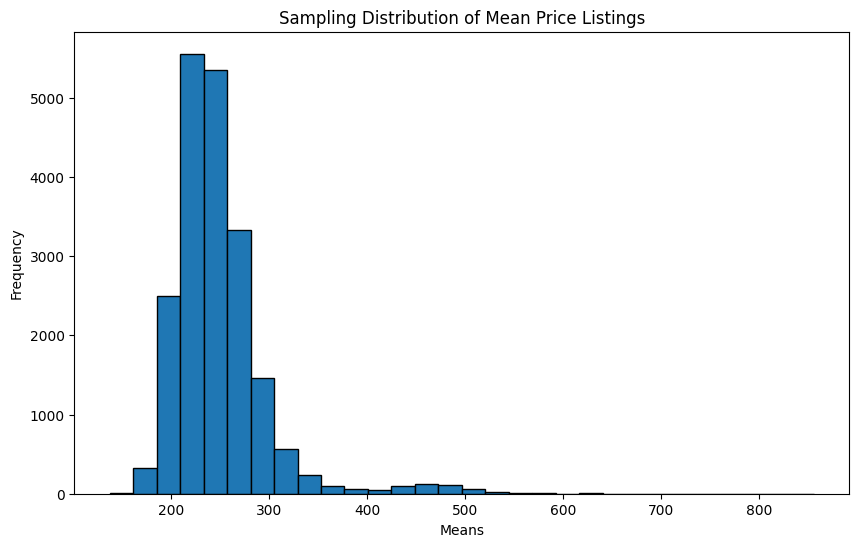

In [8]:
# Plot the histogram of the sampling distribution
plt.figure(figsize=(10, 6))
plt.hist(sample_estimates['sample_mean'], bins=30, edgecolor='black')


# Add titles and labels
plt.title('Sampling Distribution of Mean Price Listings')
plt.xlabel('Means')
plt.ylabel('Frequency')

# Show the plot
plt.show()


The sampling distribution appears to be centered around 250 and most sample mean prices range from about 220 to about 250. In fact, we can calculate the mean of the sample means.

In [9]:
sample_estimates["sample_mean"].mean()

248.71526

We see that the sample means are centered around the population mean of 222.875. This is reassuring because it means that, on average, our sample means are accurate estimates of the population mean—there’s no consistent tendency to overestimate or underestimate it.

However, in a real data analysis situation where you only have **one sample**, this suggests that your estimate could be either above or below the true population mean. To understand the uncertainty around that estimate, we can use **bootstrapping** to simulate many samples and see how much the sample means vary.

### Bootstrapping

We learned that while we can compute a point estimate from a sample and evaluate its accuracy when we have access to the full population, real-world data analysis usually involves just **one sample**. Without access to the entire population, we can't construct the exact sampling distribution, making it difficult to measure how much our sample estimate might vary.

Imagine you have a small bag of 10 marbles and want to know the average size of all marbles in the world. You can calculate the average size from your 10 marbles, but that doesn’t tell you how close your estimate is to the true average of all marbles. This is where **bootstrapping** comes in—it helps us estimate how much our average (or any point estimate) might vary if we could take different samples from the population.

Bootstrapping works by **re-sampling** from the data you already have. By creating many new samples (by randomly selecting data points with replacement), we can build a **distribution** of *possible* estimates. This distribution helps us understand how much our estimate might vary and gives us a range of likely values, which we can use to assess the uncertainty around our sample estimate.

Here's a nice video that further explains bootstrapping with visuals:
[![](./images/bootstrapping_video.png)](https://www.youtube.com/watch?v=Xz0x-8-cgaQ)

### Now, let’s see how this applies to our Airbnb example.

Instead of marbles (or medicine), we’re dealing with real-world data—specifically, Airbnb listings. Just like with the marbles, we only have one sample of listings, and we want to know how accurate our estimate (like the average price) is. By applying the **bootstrap** method to this Airbnb dataset, we can simulate many new samples from our original data and get a better sense of how much the average price might vary.

Let’s now walk through the process of creating a bootstrap distribution step-by-step using the Airbnb dataset to show how this works in code.

### Creating a Bootstrap Distribution

The **bootstrap** method helps us understand how much our sample estimate (like the mean or median) might vary by simulating many new samples from our original data. Here’s how it works, step by step:

1. **Randomly pick one data point** from your original sample.
2. **Write down the value** of that data point.
3. **Put the data point back** into the sample (so it can be picked again).
4. **Keep repeating** this process of picking and recording values until you’ve picked as many data points as were in your original sample. This gives you one new "bootstrap sample."
5. **Calculate your point estimate** (like the mean, median, or another statistic) using the bootstrap sample.
6. **Repeat steps 1–5 many times** (e.g., 10,000 times). This creates many bootstrap samples and gives you a range of estimates, called the "bootstrap distribution."
7. **Look at the range** of these estimates to see what values are reasonable for your population. This range helps us understand the uncertainty around our original estimate.

Before diving into the process of creating a bootstrap distribution, let’s first start by simply taking a sample of 40 observations from our dataset. This will give us a snapshot of the data, just like drawing a random sample from a population. We’ll use this sample to work through the concept step-by-step.

In [11]:
np.random.seed(1234)
one_sample = airbnb.sample(n=40)
# one_sample

In this example, we are taking a simple random sample of 40 rows from the airbnb dataset. This is not yet bootstrapping, but it serves as the foundation for what we’ll be doing next.

Let's visualize it:

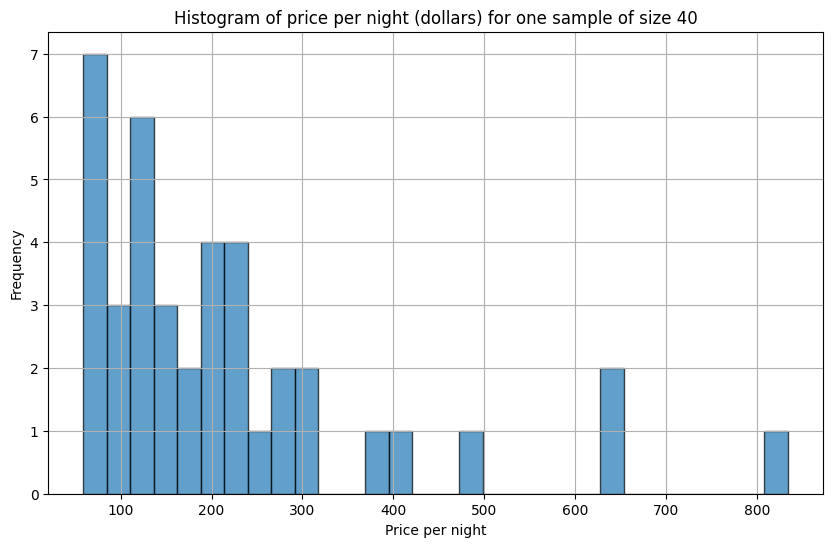

In [12]:
# Histogram of price per night (dollars) for one sample of size 40.
plt.figure(figsize=(10, 6))
plt.hist(one_sample['price'], bins=30, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Histogram of price per night (dollars) for one sample of size 40')
plt.xlabel('Price per night')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()


In [13]:
one_sample['price'].mean()

219.85

This sample has a mean price per night of $219.85 USD.

Now, to generate a bootstrap of this sample, and calculate a point estimate:

1. Generate a single bootstrap sample: Use the sample function on your DataFrame, setting `frac=1` to sample as many observations as there are rows in the DataFrame. This ensures that the bootstrap sample size matches the original sample size. Set `replace=True` to allow sampling with replacement.
2. Calculate the point estimate: Compute the point estimate (e.g., mean, median, proportion- in our case, we're looking at the mean) from the bootstrap sample.

This process generates a bootstrap sample and calculates the point estimate based on that sample. You would repeat this process many times to build the bootstrap distribution and estimate the range of plausible values for your point estimate.

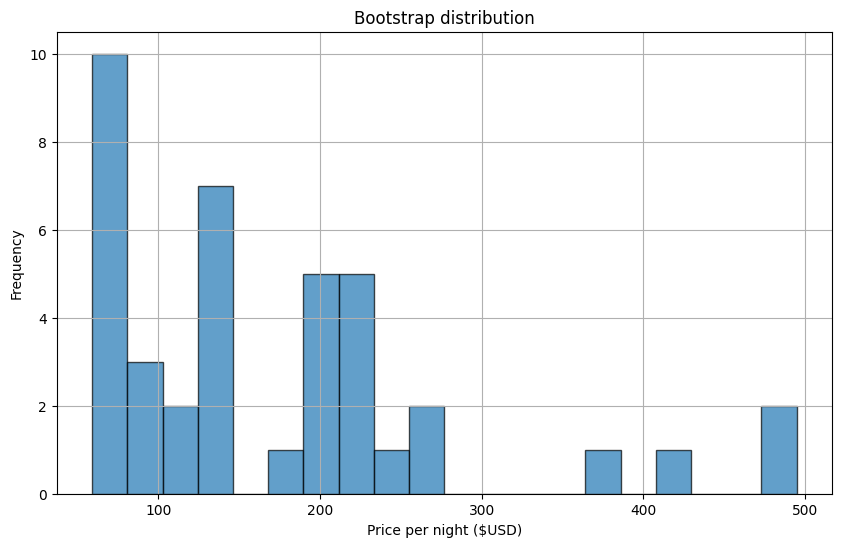

In [14]:
# Create a bootstrap sample from one_sample by sampling 100% of the rows (frac=1) with replacement.
boot1 = one_sample.sample(frac=1, replace=True)
# boot1 is the resulting bootstrap sample, where some rows may appear multiple times, and others may not appear at all.

# Plot the histogram of the bootstrap distribution
plt.figure(figsize=(10, 6))
plt.hist(boot1['price'], bins=20, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Bootstrap distribution')
plt.xlabel('Price per night ($USD)')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

In [15]:
boot1["price"].mean()

175.425

We can see that the histogram of the bootstrap sample looks similar to the original sample histogram, but they’re not exactly the same. This is because when we sample with replacement, we don’t get the exact same values as in the original sample.

We’re simulating the process of drawing a new sample from the population by using our original sample. 

Next, we'll generate **20,000 bootstrap samples** from the original sample and calculate the mean for each 🤯. Since we don’t have the full population, using the original sample this way is often the best we can do.

In [16]:
# Initialize an empty list to store the bootstrap samples
bootstrap_samples = []

for i in range(20000):
    sample = one_sample.sample(frac=1, replace=True)  # Sample with replacement
    sample = sample.assign(replicate=i)  # Add replicate number
    bootstrap_samples.append(sample)  # Store the sample

# Combine all bootstrap samples into one DataFrame
boot20000 = pd.concat(bootstrap_samples)

# Display the combined DataFrame
# boot20000

In [19]:
# Calculate the mean price for each bootstrap sample (replicate)
boot_means = boot20000.groupby('replicate')['price'].mean().reset_index(name='mean_price')
# boot_means

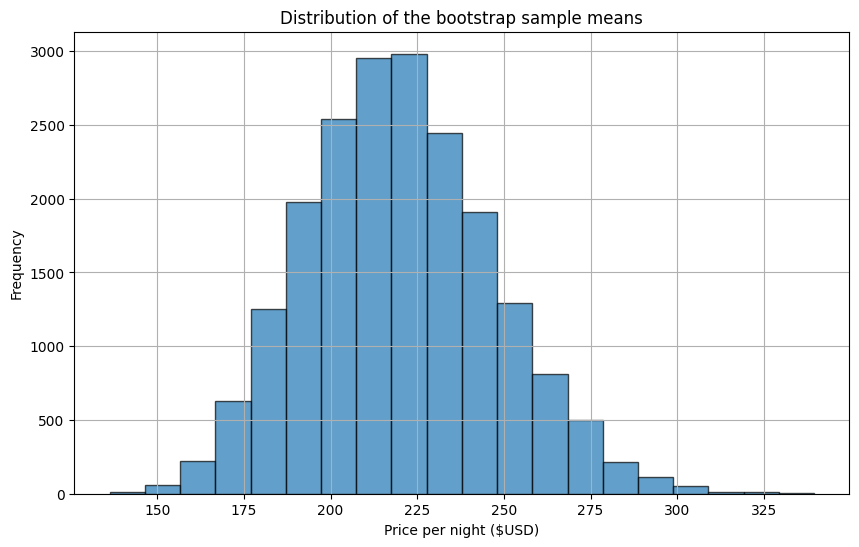

In [20]:
# Plot the histogram of the bootstrap distribution
plt.figure(figsize=(10, 6))
plt.hist(boot_means['mean_price'], bins=20, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Distribution of the bootstrap sample means')
plt.xlabel('Price per night ($USD)')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

The bootstrap distribution lets us get a sense of the point estimate’s variability.
Because we are resampling from the original sample repeatedly, we see that the bootstrap distribution is centered at the original sample’s mean value, at $219.85.

### Bootstrap to calculate a plausible range

Now that we have our bootstrap distribution, we can create a 95% confidence interval. 

> 🚨 NEW TERMINOLOGY ALERT: 🚨
>
> *Confidence Interval*
>
> A range of values that likely contains the true population parameter (such as the mean) based on your sample data. For example, a **90%** or **85%** confidence interval means that if we took many samples, the true value would fall within that range **90%** or **85%** of the time, respectively.

![](./images/confidence_interval.png)

#### Calculating the 95% Interval

1. Sort the bootstrap sample values.
2. Find the value where 2.5% of the values fall below it (lower bound).
3. Find the value where 97.5% of the values fall below it (upper bound).

The good thing about pandas is that the `quantile()` method handles these steps for us. It automatically sorts the values and finds the desired percentiles (e.g., 2.5% and 97.5%) with a simple function call.

In [21]:
# Calculate the 95% confidence interval bounds (2.5th and 97.5th percentiles) for the mean price
ci_bounds = boot_means["mean_price"].quantile([0.025, 0.975])
ci_bounds

0.025    171.248750
0.975    276.300625
Name: mean_price, dtype: float64

To wrap up our estimation, we'd report:

- **Point Estimate**: The sample mean price-per-night of 40 Airbnb listings is $219.85.
- **95% Confidence Interval**: We estimate that the true mean price-per-night for all Airbnb listings in Vancouver is between 171.44 and 275.68.

Our interval includes the true population mean (249.16), but in real-world scenarios, we wouldn’t know the true population mean because we only have one sample.

### Conclusion

In this notebook, we introduced the basics of statistical inference, laying the groundwork for more advanced techniques like testing differences between populations and assessing relationships between variables. This foundational knowledge will be crucial as you delve into more complex statistical analyses in the future! Here's a summary of what we covered:

1. **Sampling distribution**: We drew random samples and created a sampling distribution from a finite population.
2. **Bootstrapping:** We created a bootstrap distribution to approximate a sampling distribution.


We hope this notebook has provided a practical understanding of bootstrapping when estimating population parameters. Feel free to experiment further with the dataset or the code to enhance your learning!